# Electricity Demand Forecasting with a Heterogeneous Ensemble
**UPF Machine Learning Project · 2026: Didac Bustamante, Nil Castaño, Taiki Causton and Joan Garcia Almenara**

Electricity demand forecasting is important because the electricity grid needs supply and demand to stay balanced in real time. If demand is underestimated, the system can face shortages or pressure on reserves. If it is overestimated, extra generation capacity may be scheduled unnecessarily. This becomes especially relevant in systems with a high share of renewable generation, where supply can be more variable.

In this notebook, we forecast the next hour of electricity demand in Spain. The target variable is `total load actual`, measured in MWh. We use historical electricity and weather data from 2015 to 2018.

The notebook follows the full workflow of a forecasting project. We first clean and merge the energy and weather datasets. We then explore the time series, study its seasonal patterns, and create features based on calendar information, holidays, weather conditions, lagged demand, and rolling statistics. The data is split chronologically into training, validation, and test sets to avoid using future information.

We compare several models against a seasonal naive baseline. The individual models include regularized linear models, KNN, Linear SVR, Random Forest, Gradient Boosting, XGBoost, and a Multi-Layer Perceptron. We then combine the models using weighted ensemble methods. The main evaluation metric is RMSE, with MAE, MAPE, and R² also reported.

## Table of Contents
- **1. Exploration and Cleaning**
  - 1.1. Energy dataset
  - 1.2. Weather features dataset
  - 1.3. Merging the two datasets
- **2. Visualizations and Time Series Analysis**
  - 2.1. Useful visualizations and insights
  - 2.2. Decomposition and stationarity tests
  - 2.3. Autocorrelation and partial autocorrelation
- **3. Feature Engineering**
  - 3.1. Feature generation
  - 3.2. Feature selection
- **4. Electricity Demand Forecasting**
  - 4.1. Naive Forecast
  - 4.2. Ridge Regression
  - 4.3. Lasso Regression
  - 4.4. Elastic Net Regression
  - 4.5. K-Nearest Neighbors
  - 4.6. Linear SVR
  - 4.7. Random Forest
  - 4.8. Gradient Boosting
  - 4.9. XGBoost
  - 4.10. Multi-Layer Perceptron
  - 4.11. Ensemble — Weighted Average
- **5. Results**
- **6. References**

## Portfolio note

This is a four-person UPF Machine Learning project by Didac Bustamante, Nil Castaño, Taiki Causton, and Joan Garcia Almenara. The public repository does not include the raw data. See `data/README.md` for the expected files.


## Install and Import Libraries

In [90]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt
from matplotlib.patches import Patch
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import holidays

from scipy.optimize import minimize

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)
SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

---
# 1. Exploration and Cleaning

This project uses two CSV files that describe Spain's electricity system and weather conditions at an hourly frequency from 2015 to 2018.

> `weather_features.csv`: hourly weather observations for Madrid, Barcelona, Valencia, Seville, and Bilbao. The variables include temperature, humidity, wind speed, precipitation, and weather descriptions.

> `energy_dataset.csv`: hourly electricity data for Spain. It includes generation by source, total system load, and electricity prices. Although the generation columns are labelled in MW, the data is hourly, so each observation can be interpreted as an hourly energy amount.

The five cities do not cover the whole country, but they are spread across different areas of Spain and include a large share of the population. For this reason, their weather conditions are a reasonable proxy for the weather patterns that affect national electricity demand.

## 1.1. Energy dataset

In [2]:
df_energy = pd.read_csv(DATA_DIR / "energy_dataset.csv", parse_dates=["time"])
print(f"Energy dataset shape: {df_energy.shape}")
df_energy.head()

Energy dataset shape: (35064, 29)


,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [3]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal                        35046 non-null  float64
 10

In [4]:
df_energy.describe().round(0)

,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
count,35045.0,35046.0,35046.0,35046.0,35046.0,35045.0,35046.0,35046.0,35046.0,0.0,...,35045.0,35046.0,35046.0,35064.0,0.0,35064.0,35064.0,35028.0,35064.0,35064.0
mean,384.0,448.0,0.0,5623.0,4256.0,298.0,0.0,0.0,0.0,NaN,...,269.0,0.0,5464.0,1439.0,NaN,5471.0,28712.0,28697.0,50.0,58.0
std,85.0,355.0,0.0,2202.0,1962.0,53.0,0.0,0.0,0.0,NaN,...,50.0,0.0,3214.0,1678.0,NaN,3176.0,4594.0,4575.0,15.0,14.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,0.0,0.0,0.0,0.0,NaN,237.0,18105.0,18041.0,2.0,9.0
25%,333.0,0.0,0.0,4126.0,2527.0,263.0,0.0,0.0,0.0,NaN,...,240.0,0.0,2933.0,69.0,NaN,2979.0,24794.0,24808.0,41.0,49.0
50%,367.0,509.0,0.0,4969.0,4474.0,300.0,0.0,0.0,0.0,NaN,...,279.0,0.0,4849.0,576.0,NaN,4855.0,28906.0,28901.0,51.0,58.0
75%,433.0,757.0,0.0,6429.0,5839.0,330.0,0.0,0.0,0.0,NaN,...,310.0,0.0,7398.0,2636.0,NaN,7353.0,32263.0,32192.0,61.0,68.0
max,592.0,999.0,0.0,20034.0,8359.0,449.0,0.0,0.0,0.0,NaN,...,357.0,0.0,17436.0,5836.0,NaN,17430.0,41390.0,41015.0,102.0,117.0


In [5]:
# Check missing values
missing_energy = df_energy.isnull().sum()
print("Missing values per column:")
print(missing_energy[missing_energy > 0])

# Check duplicate rows
print("Duplicate rows:", df_energy.duplicated().sum())

# Check date range
print("Start date:", df_energy["time"].min())
print("End date:", df_energy["time"].max())

Missing values per column:
generation biomass                                19
generation fossil brown coal/lignite              18
generation fossil coal-derived gas                18
generation fossil gas                             18
generation fossil hard coal                       18
generation fossil oil                             19
generation fossil oil shale                       18
generation fossil peat                            18
generation geothermal                             18
generation hydro pumped storage aggregated     35064
generation hydro pumped storage consumption       19
generation hydro run-of-river and poundage        19
generation hydro water reservoir                  18
generation marine                                 19
generation nuclear                                17
generation other                                  18
generation other renewable                        18
generation solar                                  18
generation waste   

### Cleaning steps for the energy dataset

**1.** Create `price_prev_day` by shifting the actual electricity price by 24 hours. This gives the model recent price information from the same hour of the previous day without using the current hour's price.

**2.** Drop columns that are completely empty: `generation hydro pumped storage aggregated` and `forecast wind offshore eday ahead`.

**3.** Drop `price actual` and `price day ahead`, since they are not needed as direct inputs for this demand forecasting task.

**4.** Convert `time` from a UTC string into a datetime index.

In [6]:
# Convert 'time' to a local datetime index
df_energy["time"] = pd.to_datetime(df_energy["time"], utc=True).dt.tz_convert("Europe/Madrid").dt.tz_localize(None)
df_energy = df_energy.set_index("time").sort_index()

# [Feature] Previous-day electricity price:
# shift 'price actual' by 24 hours so each hour sees the price of the same hour
# on the previous day. The first 24 hours have no previous-day value -> filled with 0.
df_energy["price_prev_day"] = df_energy["price actual"].shift(24).fillna(0)

# Keep ONLY the target and the previous-day price feature.
# All other energy columns (generation, forecasts, current price) are dropped
# to avoid data leakage and noise.
df_energy = df_energy[["total load actual", "price_prev_day"]]

print(f"Energy dataset after column selection: {df_energy.shape}")
print(f"Columns kept: {list(df_energy.columns)}")

Energy dataset after column selection: (35064, 2)
Columns kept: ['total load actual', 'price_prev_day']


**5.** Before filling missing values, we check where the target variable is missing.

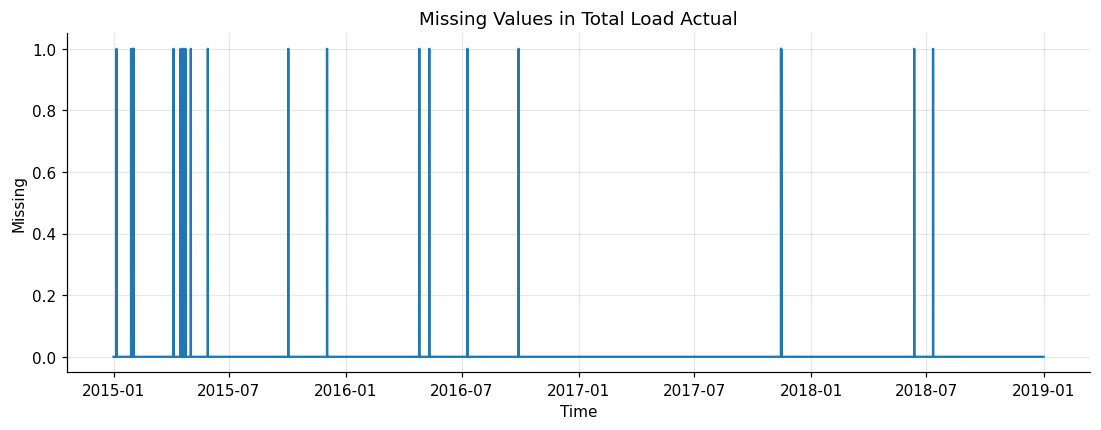

In [7]:
# Rows where the target variable is missing
df_energy[df_energy["total load actual"].isnull()]

plt.figure(figsize=(12, 4))
plt.plot(df_energy["total load actual"].isnull().astype(int))
plt.title("Missing Values in Total Load Actual")
plt.xlabel("Time")
plt.ylabel("Missing")
plt.show()

The missing values in `total load actual` only appear at a few points in the time series. Before filling them, we look at the observations around these gaps. This helps us decide whether interpolation is reasonable or whether the missing values follow a different pattern.

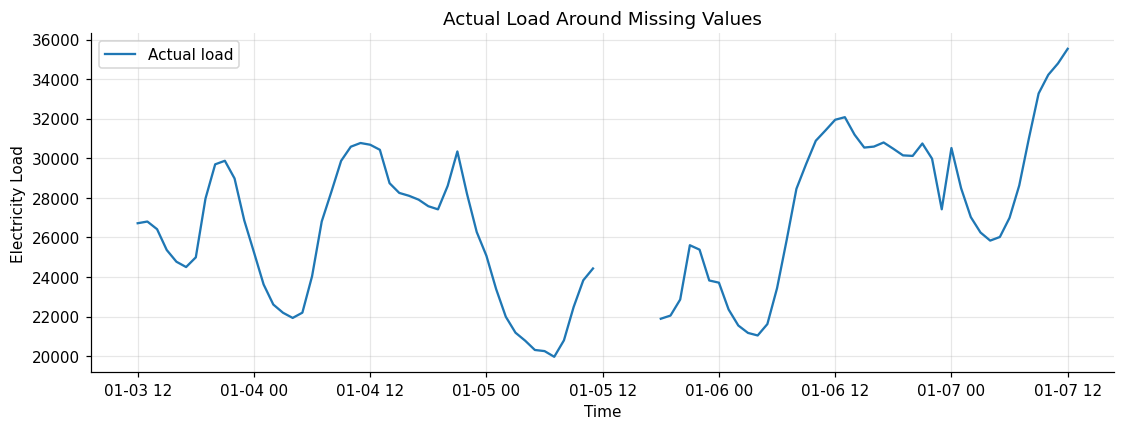

In [8]:
# Check values around the first missing target observation
missing_target_dates = df_energy[df_energy["total load actual"].isnull()].index
first_missing_date = missing_target_dates[0]

missing_period = df_energy.loc[
    first_missing_date - pd.Timedelta(days=2):
    first_missing_date + pd.Timedelta(days=2)
]

# Plot actual load around the missing period
plt.figure(figsize=(12, 4))

plt.plot(missing_period.index, missing_period["total load actual"], label="Actual load")


plt.title("Actual Load Around Missing Values")
plt.xlabel("Time")
plt.ylabel("Electricity Load")
plt.legend()
plt.show()

The missing values in `total load actual` occur over short gaps, and the surrounding observations follow a smooth pattern. For this reason, we use linear interpolation. This keeps the local trend better than replacing each missing value with the value from the same hour on the previous day.

Interpolation can add a small amount of smoothing because the filled values are estimated. However, the number of missing target values is very small compared with the full dataset, so it should not meaningfully affect the results. Since we only fill short gaps using nearby observations, this is a reasonable cleaning choice and should not create a serious leakage issue for the forecasting task.

In [9]:
# Fill missing target values using linear interpolation
df_energy["total load actual"] = df_energy["total load actual"].interpolate(method="linear")

# Fill remaining numeric missing values using linear interpolation
df_energy = df_energy.interpolate(method="linear", limit_direction="forward")

print(f"Energy dataset after cleaning: {df_energy.shape}")
print(f"Remaining missing values: {df_energy.isnull().sum().sum()}")

Energy dataset after cleaning: (35064, 2)
Remaining missing values: 0


## 1.2. Weather features dataset

In [10]:
df_weather = pd.read_csv(DATA_DIR / "weather_features.csv", parse_dates=["dt_iso"])
print(f"Weather dataset shape: {df_weather.shape}")
print(f"Cities: {df_weather['city_name'].unique()}")
df_weather.head()

Weather dataset shape: (178396, 17)
Cities: ['Valencia' 'Madrid' 'Bilbao' ' Barcelona' 'Seville']


,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [11]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_iso               178396 non-null  object 
 1   city_name            178396 non-null  object 
 2   temp                 178396 non-null  float64
 3   temp_min             178396 non-null  float64
 4   temp_max             178396 non-null  float64
 5   pressure             178396 non-null  int64  
 6   humidity             178396 non-null  int64  
 7   wind_speed           178396 non-null  int64  
 8   wind_deg             178396 non-null  int64  
 9   rain_1h              178396 non-null  float64
 10  rain_3h              178396 non-null  float64
 11  snow_3h              178396 non-null  float64
 12  clouds_all           178396 non-null  int64  
 13  weather_id           178396 non-null  int64  
 14  weather_main         178396 non-null  object 
 15  weather_descripti

In [12]:
df_weather.describe().round(0)

,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id
count,178396.0,178396.0,178396.0,178396.0,178396.0,178396.0,178396.0,178396.0,178396.0,178396.0,178396.0,178396.0
mean,290.0,288.0,291.0,1069.0,68.0,2.0,167.0,0.0,0.0,0.0,25.0,760.0
std,8.0,8.0,9.0,5970.0,22.0,2.0,117.0,0.0,0.0,0.0,31.0,109.0
min,262.0,262.0,262.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,200.0
25%,284.0,282.0,285.0,1013.0,53.0,1.0,55.0,0.0,0.0,0.0,0.0,800.0
50%,289.0,288.0,290.0,1018.0,72.0,2.0,177.0,0.0,0.0,0.0,20.0,800.0
75%,295.0,294.0,297.0,1022.0,87.0,4.0,270.0,0.0,0.0,0.0,40.0,801.0
max,316.0,315.0,321.0,1008371.0,100.0,133.0,360.0,12.0,2.0,22.0,100.0,804.0


Most variables look reasonable, but a few need to be checked before merging the weather data with the energy data.

Temperature is measured in Kelvin. Values around 270 to 310 are normal once converted to Celsius. Rain and snow variables contain many zeros, which is expected because precipitation does not occur in most hours. However, the maximum of `rain_1h` is higher than the maximum of `rain_3h`. This is unusual, since rainfall over three hours should normally include rainfall from the last hour. This suggests some reporting inconsistency in the precipitation variables.

There are also clear outliers in `pressure` and `wind_speed`. The `pressure` variable has values close to 0 and above 1,000,000, which are not realistic for atmospheric pressure. The maximum value of `wind_speed` is also very high. We use boxplots to inspect these variables before deciding how to clean them.

In [13]:
# Check missing values
missing_weather = df_weather.isnull().sum()
print("Missing values per column:")
print(missing_weather[missing_weather > 0])

# Check duplicate rows
print("Duplicate rows:", df_weather.duplicated().sum())

Missing values per column:
Series([], dtype: int64)
Duplicate rows: 21


### Cleaning steps for the weather dataset

**1.** Rename `dt_iso` to `time` and convert it to UTC datetime.

**2.** Drop duplicated observations by `(time, city_name)`, keeping the first record when the same city and hour appear more than once.

The weather dataset contains several cities, so we first sort the observations by `city_name` and `time`. This keeps each city's weather series in the correct order. When we later interpolate missing values, we do it separately for each city, so observations from one city are not used to fill values in another city.

In [14]:
# Rename and convert
df_weather = df_weather.rename(columns={"dt_iso": "time"})
df_weather["time"] = pd.to_datetime(df_weather["time"], utc=True).dt.tz_convert("Europe/Madrid").dt.tz_localize(None)
# Drop qualitative weather columns (codes/labels, not quantities)
df_weather = df_weather.drop(
    columns=["weather_id", "weather_main", "weather_description", "weather_icon"],
    errors="ignore"
)
for col in ["temp", "temp_min", "temp_max"]:
    df_weather[col] = df_weather[col] - 273.15
# Clean city names
df_weather["city_name"] = df_weather["city_name"].str.strip()

# Sort by city and time
df_weather = df_weather.sort_values(["city_name", "time"])

# Drop duplicates by city and time
df_weather = df_weather.drop_duplicates(subset=["time", "city_name"], keep="first")

**3.** We now check possible outliers in `pressure` and `wind_speed`. We first look at their distributions and then decide whether the most extreme values should be replaced, removed, or kept.

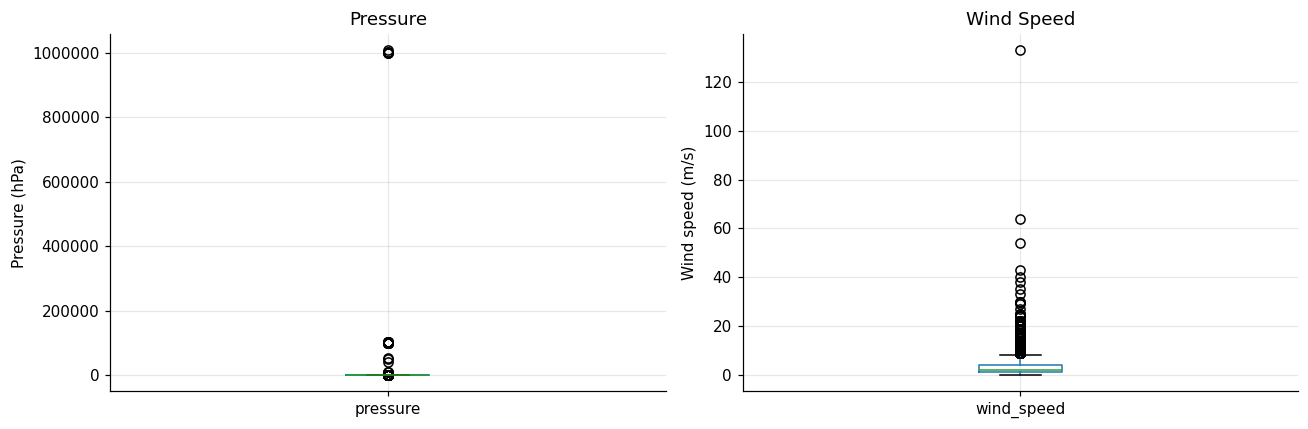

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_weather.boxplot(column="pressure", ax=axes[0])

axes[0].set_title("Pressure")

axes[0].set_ylabel("Pressure (hPa)")

axes[0].ticklabel_format(style="plain", axis="y")

df_weather.boxplot(column="wind_speed", ax=axes[1])

axes[1].set_title("Wind Speed")

axes[1].set_ylabel("Wind speed (m/s)")

plt.tight_layout()

plt.show()

For `pressure`, most observations are close to the normal atmospheric pressure range, around 1,000 hPa. However, the dataset also contains values close to 0 and values above 1,000,000 hPa. These are not realistic weather observations and are likely data errors.

For `wind_speed`, most values are much lower, but there are some extreme observations, including one above 130 m/s. Since the data is hourly and city-level, values above 50 m/s are treated as likely measurement or reporting errors.

We replace these unrealistic values with missing values and then interpolate them.

To clean the most unrealistic weather observations, we use simple cut-off rules.

For `pressure`, we keep values between 931 and 1051 hPa.

For `wind_speed`, we use 50 m/s as the cut-off. This is equal to 180 km/h, which is already an extremely high wind speed.

Instead of deleting the full rows, we replace only these unrealistic values with `NaN` and then fill them using interpolation.

In [16]:
# Replace unrealistic pressure values with NaN
df_weather.loc[(df_weather["pressure"] < 931) | (df_weather["pressure"] > 1051),"pressure"] = np.nan

# Replace unrealistic wind speed values with NaN
df_weather.loc[df_weather["wind_speed"] > 50,"wind_speed"] = np.nan

# Check missing values after replacing outliers
missing_weather = df_weather.isnull().sum()
missing_weather[missing_weather > 0]

pressure      441
wind_speed      3
dtype: int64

**4.** Interpolate the new missing values linearly, separately by city.

In [17]:
# Interpolate missing values separately for each city
df_weather["pressure"] = df_weather.groupby("city_name")["pressure"].transform(
    lambda x: x.interpolate(method="linear", limit_direction='both'))

df_weather["wind_speed"] = df_weather.groupby("city_name")["wind_speed"].transform(
    lambda x: x.interpolate(method="linear", limit_direction='both'))

# Check remaining missing values
missing_weather = df_weather.isnull().sum()
missing_weather[missing_weather > 0]

Series([], dtype: int64)

After interpolation, there are no missing values left in the weather dataset. This means the unrealistic `pressure` and `wind_speed` observations have been replaced successfully.

**6.** Check the precipitation variables and drop the inconsistent rainfall measure.

In [18]:
# Check cases where rain_1h is greater than rain_3h
rain_issue = df_weather[df_weather["rain_1h"] > df_weather["rain_3h"]]

rain_issue[["time", "city_name", "rain_1h", "rain_3h"]].head()

,time,city_name,rain_1h,rain_3h
107515,2015-01-07 08:00:00,Barcelona,0.3,0.0
107516,2015-01-07 09:00:00,Barcelona,0.3,0.0
107518,2015-01-07 11:00:00,Barcelona,0.3,0.0
107520,2015-01-07 13:00:00,Barcelona,0.3,0.0
107521,2015-01-07 14:00:00,Barcelona,0.3,0.0


The check shows that there are observations where `rain_1h` is positive while `rain_3h` is zero. This suggests that `rain_3h` is not reported consistently. Since the dataset is hourly, `rain_1h` is also better aligned with the frequency of the data. For this reason, we keep `rain_1h` and drop `rain_3h`.

In [19]:
# Drop rain_3h because it appears inconsistent with rain_1h
df_weather = df_weather.drop(columns=["rain_3h"])

# Check that it was dropped
df_weather.columns

Index(['time', 'city_name', 'temp', 'temp_min', 'temp_max', 'pressure',
       'humidity', 'wind_speed', 'wind_deg', 'rain_1h', 'snow_3h',
       'clouds_all'],
      dtype='object')

## 1.3. Merging the two datasets

In [20]:
# Select numerical weather variables
num_cols = df_weather.select_dtypes(include=[np.number]).columns

# Convert weather data from long format to wide format
df_weather_pivot = df_weather.pivot_table(index="time", columns="city_name", values=num_cols)

# Rename columns to make them easier to use
df_weather_pivot.columns = [f"{variable}_{city}" for variable, city in df_weather_pivot.columns]

# Merge energy and weather datasets by time
df = df_energy.join(df_weather_pivot, how="left")

# Drop rows where the target variable is missing
df = df.dropna(subset=["total load actual"])

# Check final merged dataset
print(f"Merged dataset: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")

Merged dataset: (35064, 52)
Date range: 2015-01-01 00:00:00 → 2018-12-31 23:00:00


---
# 2. Visualizations and Time Series Analysis

This section looks at the main patterns in electricity demand. These patterns guide the feature engineering choices in Section 3.

## 2.1. Useful visualizations and insights

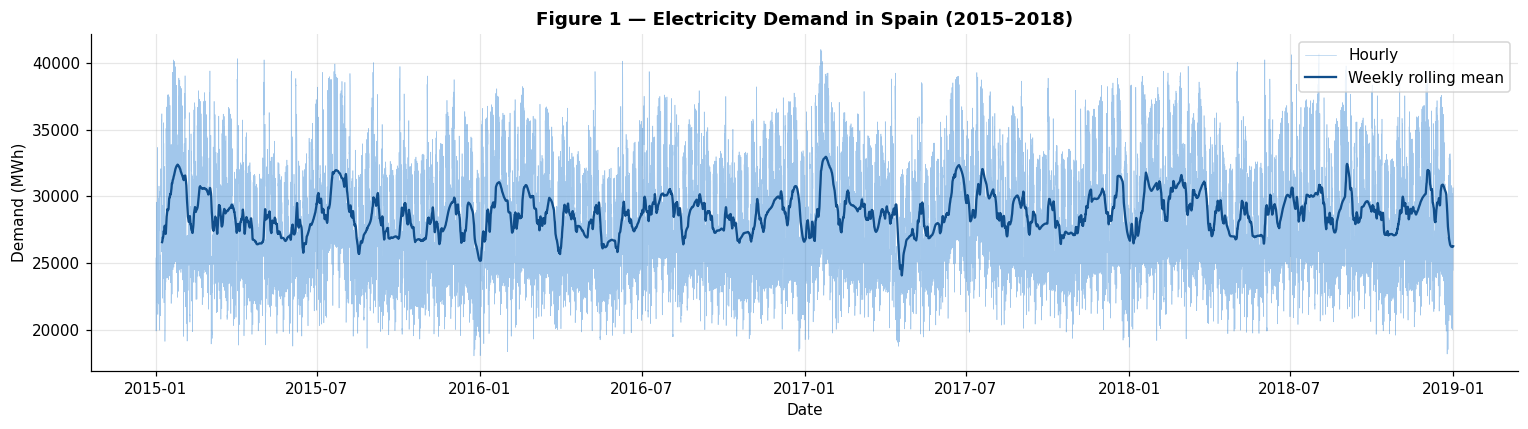

In [21]:
# Full demand series with weekly rolling mean
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df["total load actual"], color="#1874cd", alpha=0.4, lw=0.4, label="Hourly")
ax.plot(df.index, df["total load actual"].rolling(168).mean(),color="#104e8b", lw=1.5, label="Weekly rolling mean")
ax.set_title("Figure 1 — Electricity Demand in Spain (2015–2018)",fontsize=12, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Demand (MWh)")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig1_demand_series.png", dpi=150, bbox_inches="tight")
plt.show()

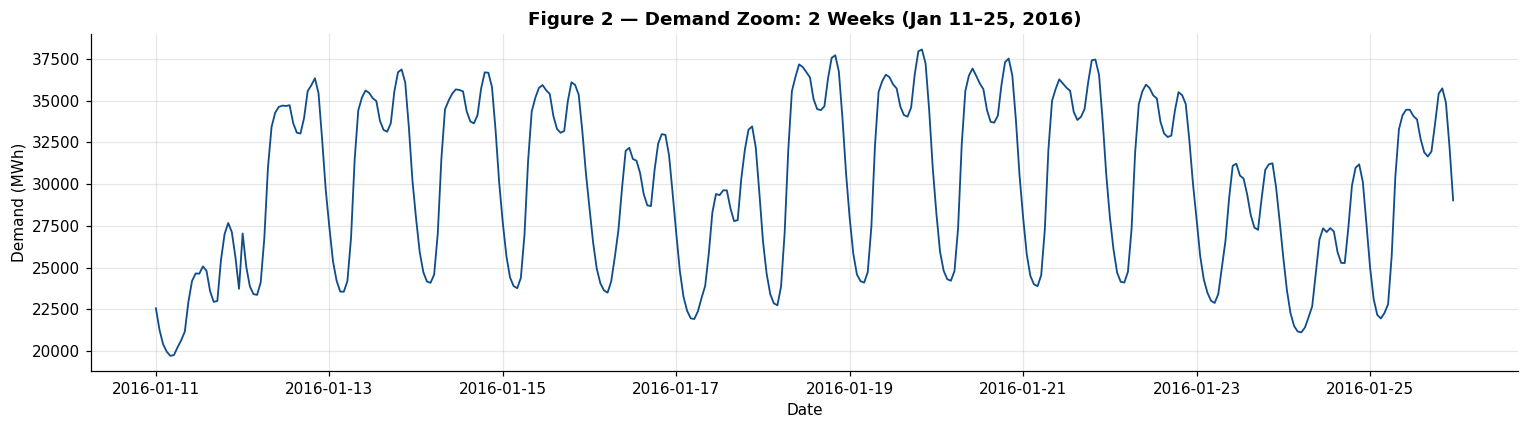

In [22]:
# Zoom: 2 weeks (mid-January 2016) to see intraday and weekly patterns
zoom = df.loc["2016-01-11":"2016-01-25", "total load actual"]
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(zoom.index, zoom.values, color="#104e8b", lw=1.2)
ax.set_title("Figure 2 — Demand Zoom: 2 Weeks (Jan 11–25, 2016)",fontsize=12, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Demand (MWh)")
plt.tight_layout()
plt.savefig("figures/fig2_demand_zoom.png", dpi=150, bbox_inches="tight")
plt.show()

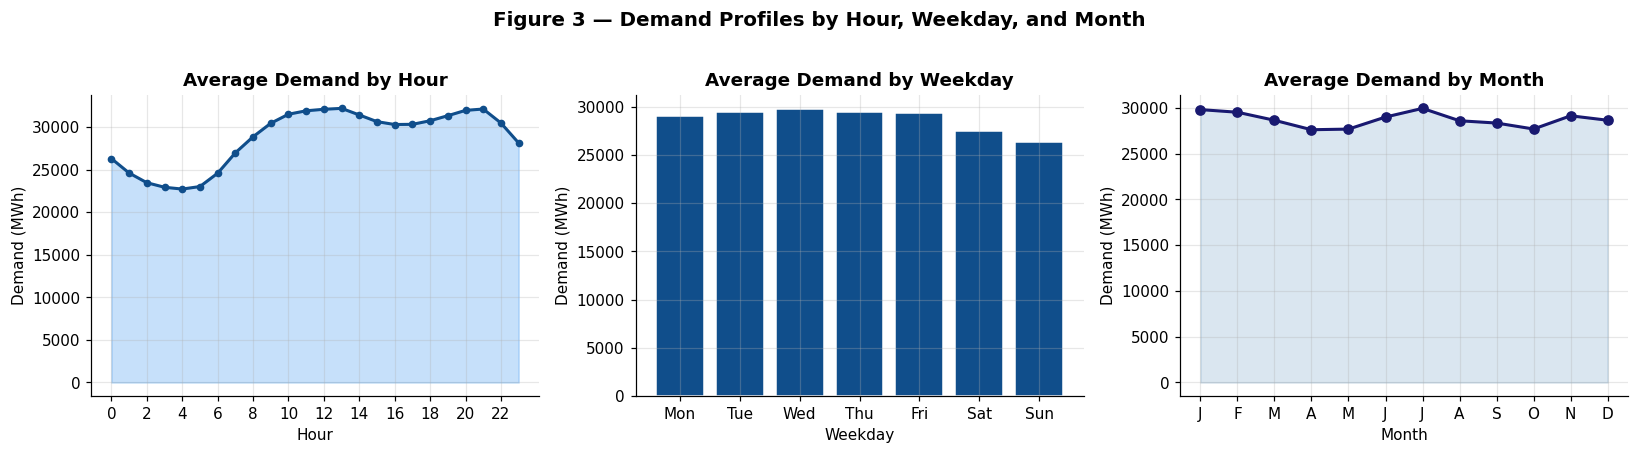

In [23]:
# Daily, weekly and monthly profiles
df_tmp = df.copy()
df_tmp["hour"] = df_tmp.index.hour
df_tmp["weekday"] = df_tmp.index.dayofweek
df_tmp["month"] = df_tmp.index.month

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Hourly
hourly = df_tmp.groupby("hour")["total load actual"].mean()
axes[0].fill_between(hourly.index, hourly.values, alpha=0.25, color="#1c86ee")
axes[0].plot(hourly.index, hourly.values, color="#104e8b", lw=2, marker="o", ms=4)
axes[0].set_title("Average Demand by Hour", fontweight="bold")
axes[0].set_xlabel("Hour"); axes[0].set_ylabel("Demand (MWh)")
axes[0].set_xticks(range(0, 24, 2))

# Weekday
weekday = df_tmp.groupby("weekday")["total load actual"].mean()
axes[1].bar(weekday.index, weekday.values, color="#104e8b", edgecolor="white")
axes[1].set_title("Average Demand by Weekday", fontweight="bold")
axes[1].set_xlabel("Weekday"); axes[1].set_ylabel("Demand (MWh)")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])

# Monthly
monthly = df_tmp.groupby("month")["total load actual"].mean()
axes[2].plot(monthly.index, monthly.values, color="#191970", lw=2, marker="o", ms=6)
axes[2].fill_between(monthly.index, monthly.values, alpha=0.2, color="#4682B4")
axes[2].set_title("Average Demand by Month", fontweight="bold")
axes[2].set_xlabel("Month"); axes[2].set_ylabel("Demand (MWh)")
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])

plt.suptitle("Figure 3 — Demand Profiles by Hour, Weekday, and Month",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig3_profiles.png", dpi=150, bbox_inches="tight")
plt.show()



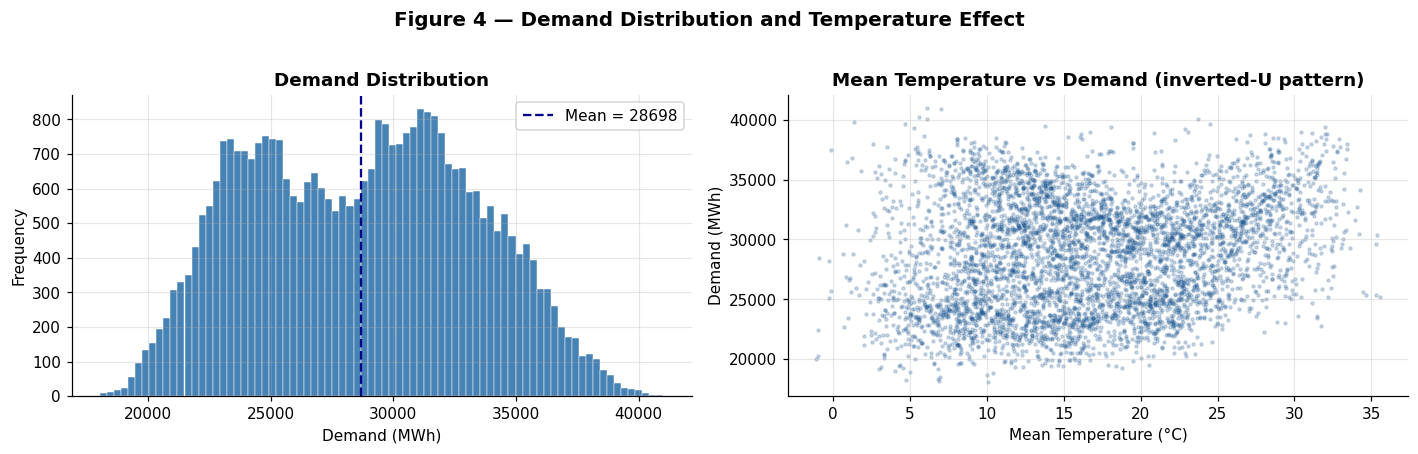

In [96]:
# Histogram + temperature-vs-demand scatter
df_tmp["temp_mean"] = df_tmp[[f"temp_{c}" for c in ["Madrid","Barcelona","Valencia","Seville","Bilbao"]]].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(df_tmp["total load actual"], bins=80, color="#4682B4", edgecolor="white", lw=0.3)
axes[0].axvline(df_tmp["total load actual"].mean(), color="darkblue", lw=1.5, ls="--",
                label=f"Mean = {df_tmp['total load actual'].mean():.0f}")
axes[0].set_title("Demand Distribution", fontweight="bold")
axes[0].set_xlabel("Demand (MWh)"); axes[0].set_ylabel("Frequency")
axes[0].legend()

# Temperature vs demand: expected inverted-U shape
sample = df_tmp.sample(min(5000, len(df_tmp)), random_state=SEED)
axes[1].scatter(sample["temp_mean"], sample["total load actual"],
                alpha=0.2, s=4, color="#104e8b")
axes[1].set_title("Mean Temperature vs Demand (inverted-U pattern)",
                  fontweight="bold")
axes[1].set_xlabel("Mean Temperature (°C)"); axes[1].set_ylabel("Demand (MWh)")

plt.suptitle("Figure 4 — Demand Distribution and Temperature Effect",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig4_dist_temp.png", dpi=150, bbox_inches="tight")
plt.show()

The histogram shows that most electricity demand observations are concentrated around the middle of the distribution, with fewer values at very low or very high demand levels. The temperature scatter plot suggests a nonlinear relationship. Demand is higher when temperatures move away from mild levels, which supports adding a temperature-deviation feature.

**Key insights from the visualizations:**

- **Daily pattern:** demand follows a clear daily cycle. It increases in the morning, reaches a higher level during the day, and drops overnight.
- **Weekly pattern:** demand is lower on weekends than on weekdays, which is consistent with lower industrial and commercial activity.
- **Seasonal pattern:** demand is higher in both summer and winter, mainly because of cooling and heating needs. Spring and autumn usually have lower demand.
- **Temperature relationship:** demand is higher at low temperatures and high temperatures, with a lower point around mild temperatures. This supports adding a nonlinear temperature feature in Section 3.

## 2.2. Decomposition and stationarity tests

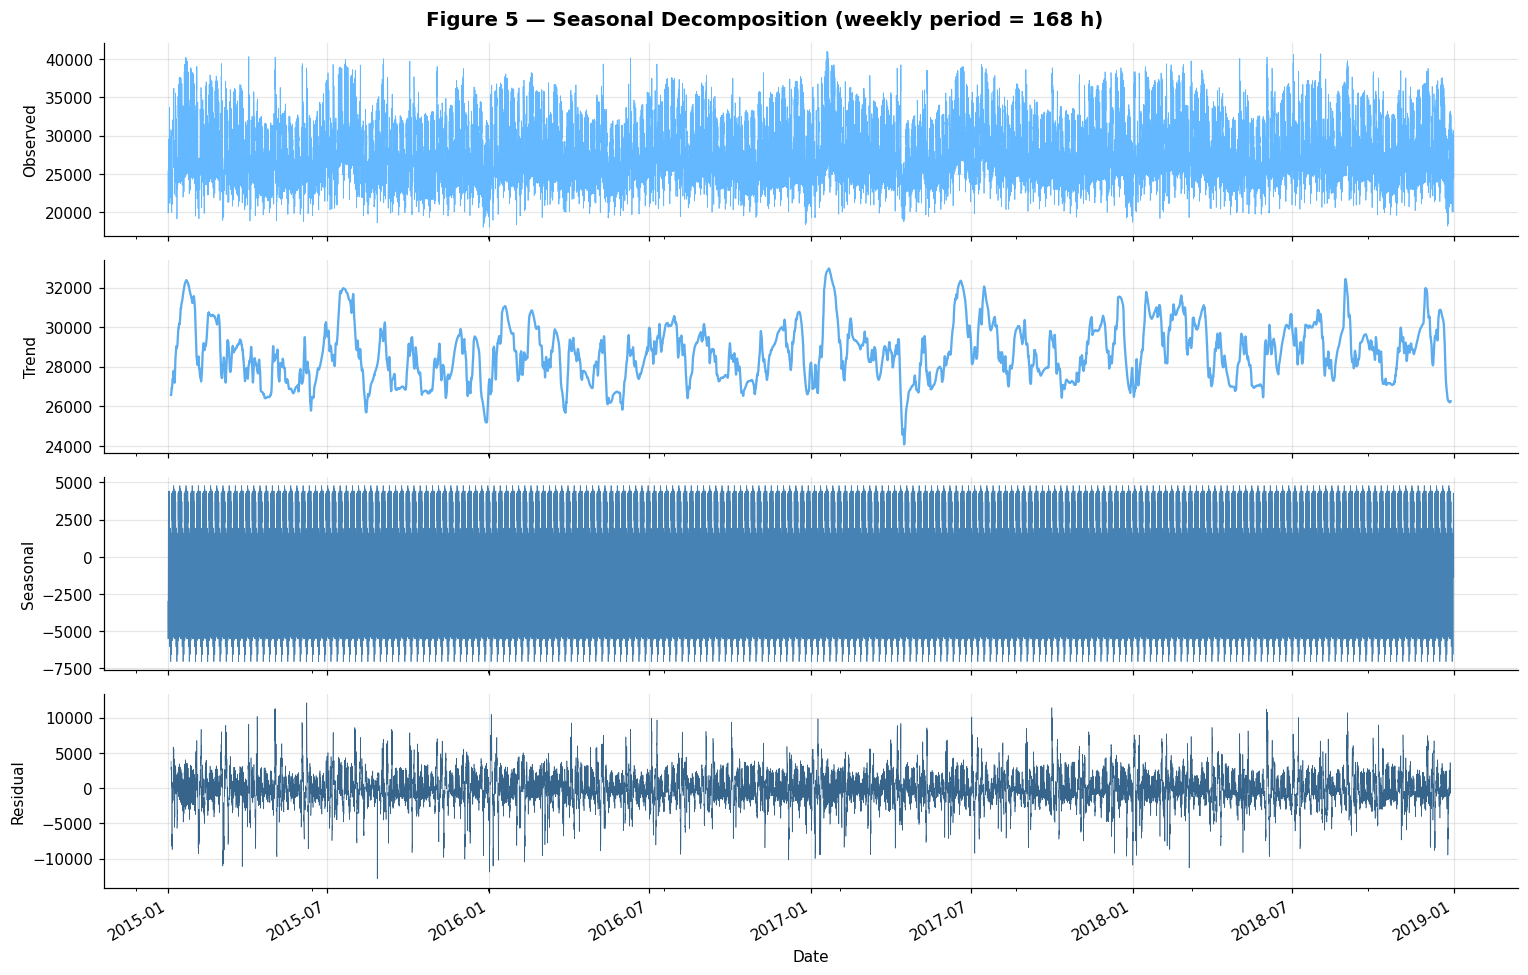

In [25]:
# Seasonal decomposition (weekly period = 24*7 = 168 hours)
ts = df["total load actual"]
decomp = seasonal_decompose(ts, model="additive", period=168)

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
decomp.observed.plot(ax=axes[0], color="#63b8ff", lw=0.5)
axes[0].set_ylabel("Observed")
decomp.trend.plot(ax=axes[1], color="#5cacee", lw=1.5)
axes[1].set_ylabel("Trend")
decomp.seasonal.plot(ax=axes[2], color="#4682b4", lw=0.5)
axes[2].set_ylabel("Seasonal")
decomp.resid.plot(ax=axes[3], color="#36648b", lw=0.4)
axes[3].set_ylabel("Residual"); axes[3].set_xlabel("Date")
plt.suptitle("Figure 5 — Seasonal Decomposition (weekly period = 168 h)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig5_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
# Stationarity tests on a sample (full series can be slow)
sample = ts.iloc[:8760]   # first year

adf  = adfuller(sample, autolag="AIC")
kp   = kpss(sample, regression="c", nlags="auto")

print("=== Stationarity Tests (first year of data) ===")
print(f"ADF  test:  statistic = {adf[0]:>8.3f}  | p-value = {adf[1]:.4f}  "
      f"→ {'STATIONARY' if adf[1] < 0.05 else 'NON-STATIONARY'} (reject H₀ if p < 0.05)")
print(f"KPSS test:  statistic = {kp[0]:>8.3f}  | p-value = {kp[1]:.4f}  "
      f"→ {'STATIONARY' if kp[1] > 0.05 else 'NON-STATIONARY'} (fail to reject H₀ if p > 0.05)")

=== Stationarity Tests (first year of data) ===
ADF  test:  statistic =  -10.919  | p-value = 0.0000  → STATIONARY (reject H₀ if p < 0.05)
KPSS test:  statistic =    0.747  | p-value = 0.0100  → NON-STATIONARY (fail to reject H₀ if p > 0.05)
/tmp/ipykernel_187/1429375788.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp   = kpss(sample, regression="c", nlags="auto")


To understand the demand series better, we apply seasonal decomposition and separate it into trend, seasonal, and residual components. We also run ADF and KPSS tests on the first year of data to check whether the series appears stationary. This helps us understand the stability of the series before creating lag and rolling features.

## 2.3. Autocorrelation and partial autocorrelation

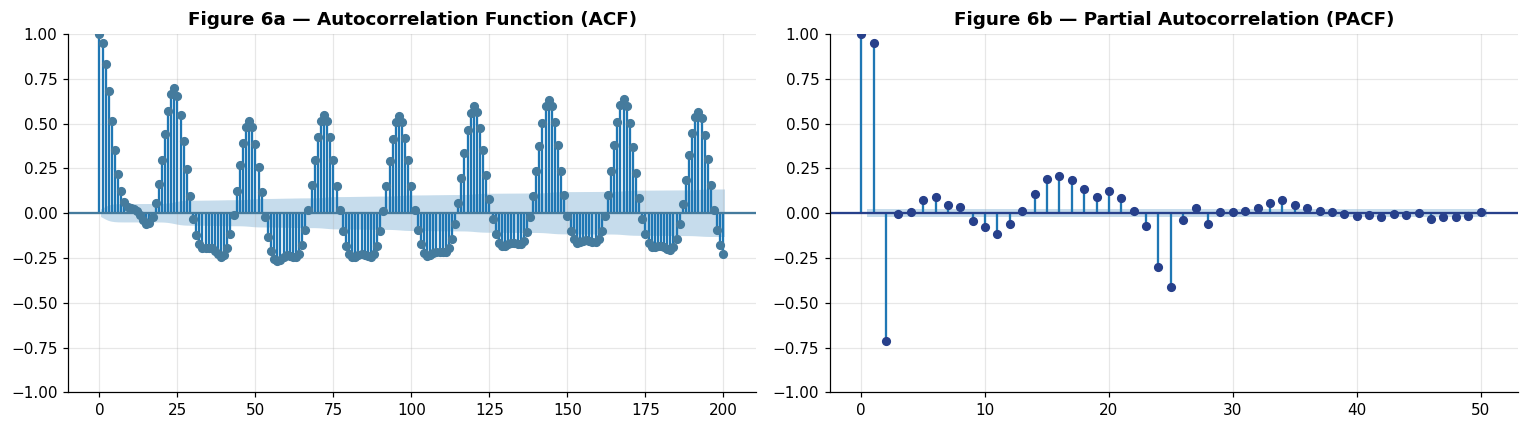

In [27]:
sample = ts.iloc[:8760]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(sample, lags=200, ax=axes[0], color="#457B9D")
axes[0].set_title("Figure 6a — Autocorrelation Function (ACF)", fontweight="bold")

plot_pacf(sample, lags=50, ax=axes[1], color="#27408b", method="ywm")
axes[1].set_title("Figure 6b — Partial Autocorrelation (PACF)", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/fig6_acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()

**Key insights from ACF/PACF:**

- Strong autocorrelation at lag 1: previous hour.
- Strong autocorrelation at lag 24: same hour on the previous day.
- Strong autocorrelation at lag 168: same hour on the previous week.

These three lags are used as lag features in Section 3.

# 3. Feature Engineering

We create features based on time, calendar effects, holidays, lagged demand, rolling statistics, temperature transformations, and interactions. The lag choices come mainly from the ACF and PACF results.

## 3.1. Feature generation

### Temporal features + cyclic encoding

In [28]:
# Make sure the index is datetime
df.index = pd.to_datetime(df.index)

# Create time features
df["hour"] = df.index.hour
df["weekday"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)
df["year"] = df.index.year 

# Cyclic encoding (sin/cos) — preserves distance between hour 23 and hour 0
df["hour_sin"]    = np.sin(2 * np.pi * df["hour"]    / 24)
df["hour_cos"]    = np.cos(2 * np.pi * df["hour"]    / 24)
df["weekday_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
df["weekday_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)
df["month_sin"]   = np.sin(2 * np.pi * df["month"]   / 12)
df["month_cos"]   = np.cos(2 * np.pi * df["month"]   / 12)

### Business hour pattern (Spanish siesta)

In [29]:
# Business hour dummy variables
df["is_siesta"] = ((df["hour"] >= 14) & (df["hour"] < 17)).astype(int)

df["is_working_hour"] = (
    ((df["hour"] >= 9) & (df["hour"] < 14)) |
    ((df["hour"] >= 17) & (df["hour"] < 21))
).astype(int)

We include `is_siesta` and `is_working_hour` because electricity demand changes across the day. In Section 2.1, weekday demand increased during the morning, dipped slightly during the 14:00–17:00 period, and then rose again later in the day.

This is consistent with daily routines in Spain, where some activity slows down around lunch time. Using separate dummy variables for siesta hours and working hours allows the model to capture this pattern without treating the categories as ordered numerical values.

### Spanish holidays

In [30]:
# Spanish holidays
es_holidays = holidays.Spain(years=list(range(2015, 2019)))

df["is_holiday"] = df.index.normalize().isin(es_holidays).astype(int)

print(f"Holidays detected: {df['is_holiday'].sum():,} hours " f"({df['is_holiday'].sum()/24:.0f} days)")

Holidays detected: 840 hours (35 days)


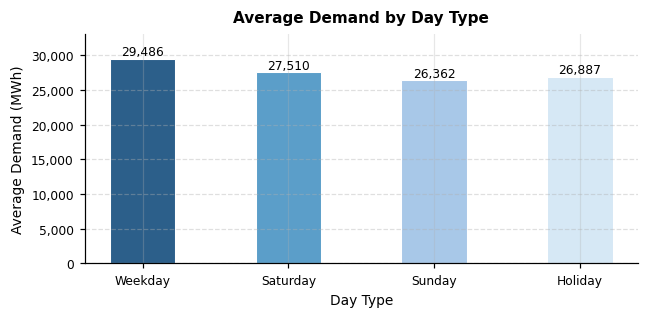

In [31]:
# Temporary labels only for the graph
df["day_type_label"] = "Weekday"
df.loc[df.index.dayofweek == 5, "day_type_label"] = "Saturday"
df.loc[df.index.dayofweek == 6, "day_type_label"] = "Sunday"
df.loc[df["is_holiday"] == 1, "day_type_label"] = "Holiday"

avg_demand_day = df.groupby("day_type_label")["total load actual"].mean()

fig, ax = plt.subplots(figsize=(6, 3))

order = ["Weekday", "Saturday", "Sunday", "Holiday"]
values = avg_demand_day.loc[order]

bars = ax.bar(order, values, color=["#2C5F8A", "#5B9EC9", "#A8C8E8", "#D6E8F5"], edgecolor="white",
    linewidth=0.7,width=0.45)


for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100, f"{bar.get_height():,.0f}",
        ha="center", va="bottom",fontsize=8)

ax.set_title("Average Demand by Day Type", fontsize=10, fontweight="bold", pad=8)
ax.set_xlabel("Day Type", fontsize=9)
ax.set_ylabel("Average Demand (MWh)", fontsize=9)
ax.set_ylim(0, values.max() * 1.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="both", labelsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Drop temporary plotting label
df = df.drop(columns=["day_type_label"])

The graph shows that demand differs across day types. Holidays do not behave exactly like normal weekdays or weekends, so we include `is_holiday` as a separate feature.

### Lag features (motivated by ACF/PACF)

The ACF and PACF plots show that current electricity demand depends strongly on past demand. To capture this time dependence without using future information, we create three lag features from the target variable:

* **`load_lag_1` ($\text{t}-1$):** captures short-term persistence from the previous hour.
* **`load_lag_24` ($\text{t}-24$):** captures the daily pattern by using demand from the same hour on the previous day.
* **`load_lag_168` ($\text{t}-168$):** captures the weekly pattern by using demand from the same hour one week earlier.

In [32]:
TARGET = "total load actual"
df["load_lag_1"]   = df[TARGET].shift(1)
df["load_lag_24"]  = df[TARGET].shift(24)
df["load_lag_168"] = df[TARGET].shift(168)

### Moving Window Statistics (Rolling Features)

We calculate rolling statistics over a 24-hour window to capture short-term trends and changes in demand variability.

We apply `.shift(1)` before computing the rolling mean and standard deviation. This is important because the feature at time $t$ should only use information available up to time $t-1$. This avoids looking ahead into the target period.

* `load_roll_24h_mean`: the average demand over the previous 24 hours.
* `load_roll_24h_std`: the standard deviation of demand over the previous 24 hours.

In [33]:
# shift(1) before rolling to avoid leakage from the current hour
df["load_roll_24h_mean"] = df[TARGET].shift(1).rolling(24).mean()
df["load_roll_24h_std"]  = df[TARGET].shift(1).rolling(24).std()
df["load_roll_7d_mean"]  = df[TARGET].shift(1).rolling(168).mean()

### Temperature Features (Weighted, Quadratic, and Range)

Temperature is one of the main weather variables related to electricity demand. To capture this without adding too many city-level variables, we create three temperature-based features:

* **Population-weighted temperature** (`temp_weighted`): temperatures from Madrid, Barcelona, Valencia, Seville, and Bilbao are averaged using population weights. This gives more importance to weather conditions in larger cities.
* **Temperature deviation** (`temp_weighted_sq`): demand is usually lower at mild temperatures and higher when it is very cold or very hot. We therefore calculate the squared distance from 18°C instead of simply squaring temperature. This captures both heating and cooling effects.
* **Thermal range per city** (`temp_range_{c}`): for each city, we calculate the difference between daily maximum and minimum temperature. This captures how much temperature changes within the day.

In [34]:
cities  = ["Madrid", "Barcelona", "Valencia", "Seville", "Bilbao"]
weights = {"Madrid":0.405, "Barcelona":0.341, "Valencia":0.108, "Seville":0.086, "Bilbao":0.065}

# Population-weighted mean temperature across the 5 cities
df["temp_weighted"] = sum(df[f"temp_{c}"] * w for c, w in weights.items())

# [S5] Quadratic temperature — captures inverted-U (heating + cooling)
df["temp_weighted_sq"] = (df["temp_weighted"]-18) ** 2

# Temperature range per city (max - min)
for c in cities:
    df[f"temp_range_{c}"] = df[f"temp_max_{c}"] - df[f"temp_min_{c}"]

### Interactions

In [35]:
# Temperature interaction features
df["temp_sq_x_weekend"] = df["temp_weighted_sq"] * df["is_weekend"]
df["temp_sq_x_holiday"] = df["temp_weighted_sq"] * df["is_holiday"]

We include interaction variables because the effect of temperature may depend on the type of day. Demand changes by hour, weekday, weekend, month, and holiday status.

For example, very hot or very cold weather may affect demand differently on a normal weekday than on a weekend or public holiday. People's routines and electricity use are not the same across these days.

The interaction `temp_sq_x_weekend` allows the temperature effect to differ on weekends. The interaction `temp_sq_x_holiday` does the same for public holidays.

## 3.2. Feature selection

In [36]:
print("Energy index:")
print(df_energy.index.min(), "to", df_energy.index.max())

print("Weather pivot index:")
print(df_weather_pivot.index.min(), "to", df_weather_pivot.index.max())

Energy index:
2015-01-01 00:00:00 to 2018-12-31 23:00:00
Weather pivot index:
2015-01-01 00:00:00 to 2018-12-31 23:00:00


In [37]:
# Population-weighted weather variables
cities = ["Madrid", "Barcelona", "Valencia", "Seville", "Bilbao"]
weights = {"Madrid":0.405, "Barcelona":0.341, "Valencia":0.108, "Seville":0.086, "Bilbao":0.065}

df["humidity_weighted"] = sum(df[f"humidity_{city}"] * weight for city, weight in weights.items())
df["pressure_weighted"] = sum(df[f"pressure_{city}"] * weight for city, weight in weights.items())
df["wind_speed_weighted"] = sum(df[f"wind_speed_{city}"] * weight for city, weight in weights.items())
df["rain_1h_weighted"] = sum(df[f"rain_1h_{city}"] * weight for city, weight in weights.items())
df["snow_3h_weighted"] = sum(df[f"snow_3h_{city}"] * weight for city, weight in weights.items())
df["clouds_all_weighted"] = sum(df[f"clouds_all_{city}"] * weight for city, weight in weights.items())

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35064 entries, 2015-01-01 00:00:00 to 2018-12-31 23:00:00
Data columns (total 87 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total load actual     35064 non-null  float64
 1   price_prev_day        35064 non-null  float64
 2   clouds_all_Barcelona  35064 non-null  float64
 3   clouds_all_Bilbao     35064 non-null  float64
 4   clouds_all_Madrid     35064 non-null  float64
 5   clouds_all_Seville    35064 non-null  float64
 6   clouds_all_Valencia   35064 non-null  float64
 7   humidity_Barcelona    35064 non-null  float64
 8   humidity_Bilbao       35064 non-null  float64
 9   humidity_Madrid       35064 non-null  float64
 10  humidity_Seville      35064 non-null  float64
 11  humidity_Valencia     35064 non-null  float64
 12  pressure_Barcelona    35064 non-null  float64
 13  pressure_Bilbao       35064 non-null  float64
 14  pressure_Madrid       35064 non-nul

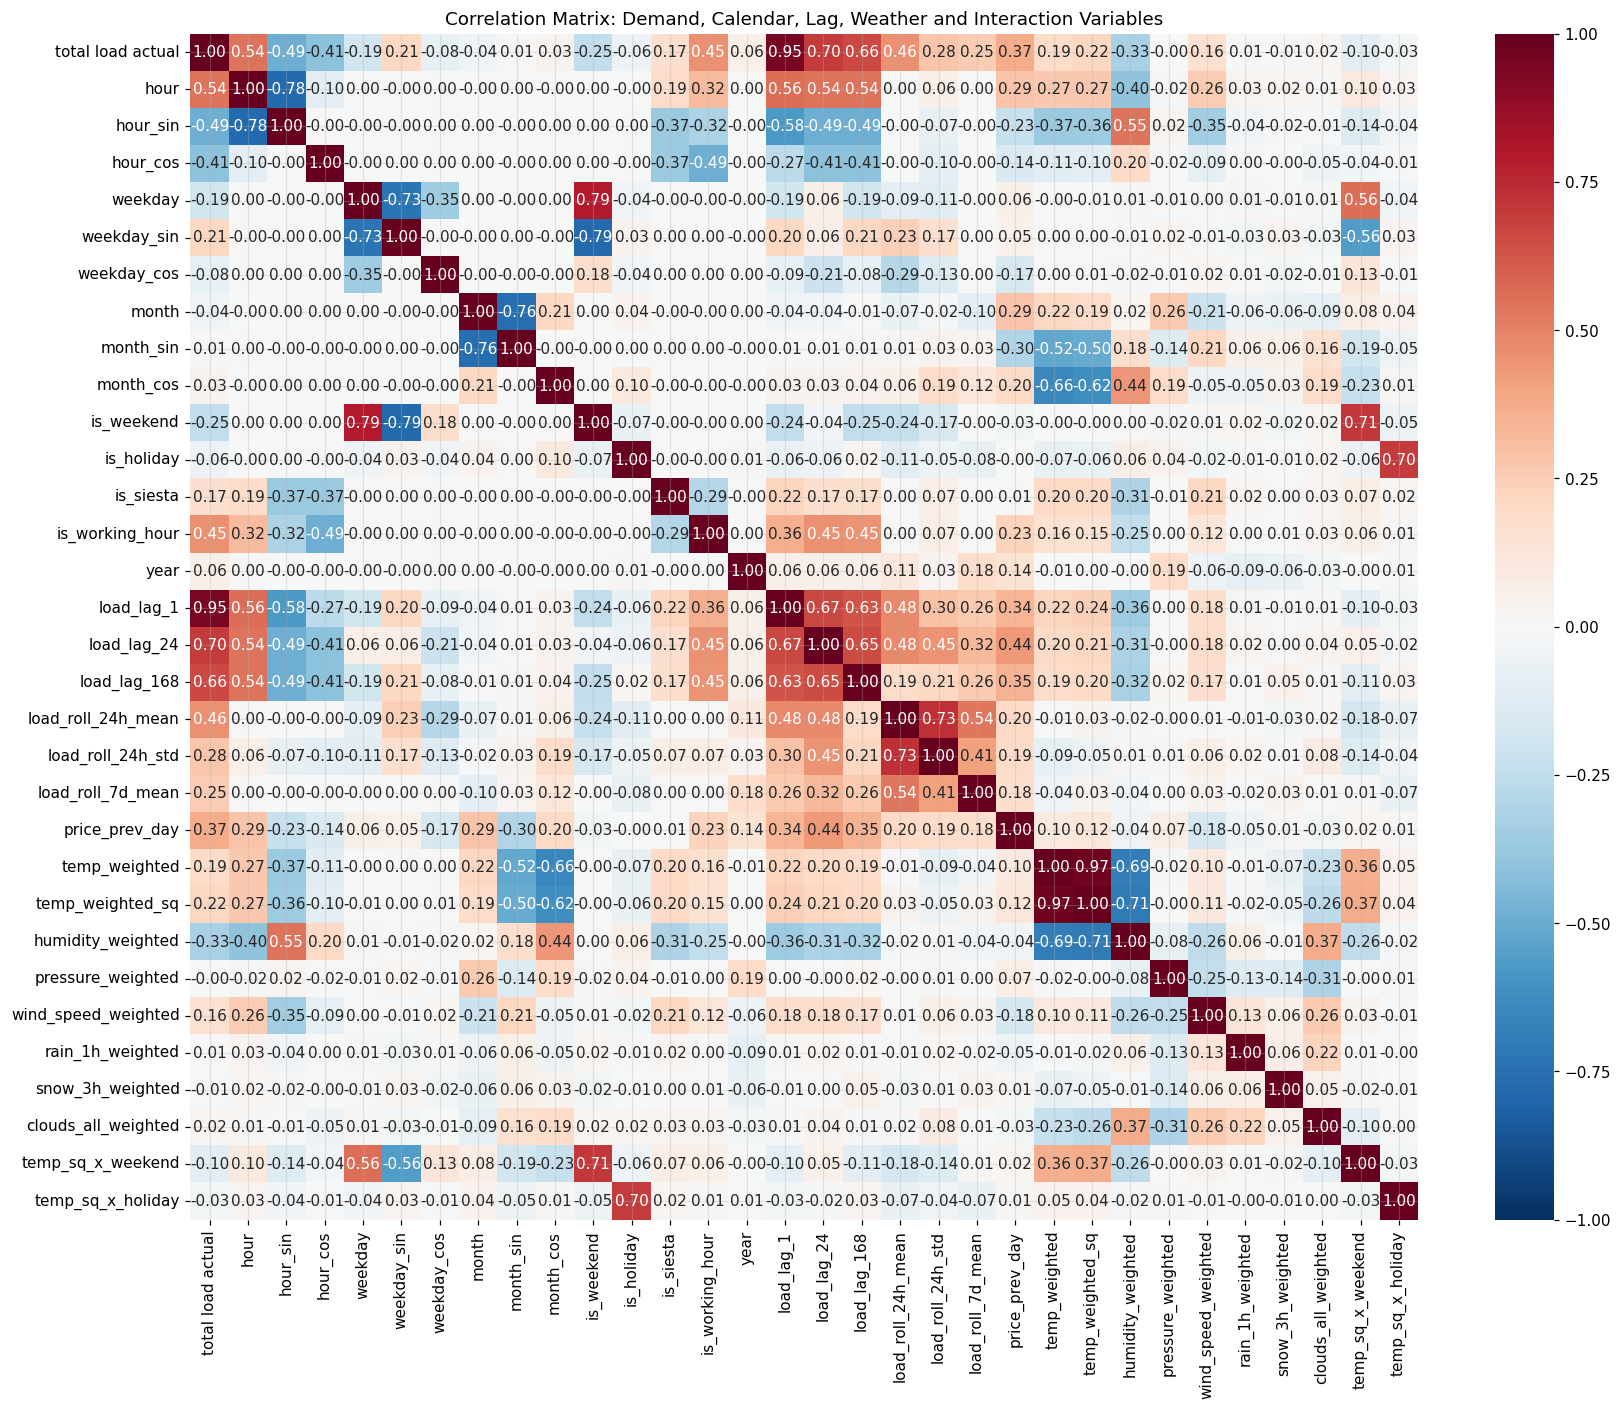

In [39]:
# Select variables for a broader correlation matrix
corr_cols = [
    "total load actual",
    
    # Time/calendar variables
    "hour", "hour_sin", "hour_cos", "weekday", "weekday_sin", "weekday_cos", "month", "month_sin",
    "month_cos", "is_weekend", "is_holiday", "is_siesta", "is_working_hour", "year",
    
    # Lag, rolling and price variables
    "load_lag_1", "load_lag_24", "load_lag_168", "load_roll_24h_mean", "load_roll_24h_std", "load_roll_7d_mean",
    "price_prev_day",
    
    # Weather variables
    "temp_weighted", "temp_weighted_sq", "humidity_weighted", "pressure_weighted", "wind_speed_weighted", 
    "rain_1h_weighted", "snow_3h_weighted", "clouds_all_weighted",
    
    # Interaction variables
    "temp_sq_x_weekend", "temp_sq_x_holiday"
    ]


corr_cols = [col for col in corr_cols if col in df.columns]
corr_matrix = df[corr_cols].corr()
plt.figure(figsize=(18, 14))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)

plt.title("Correlation Matrix: Demand, Calendar, Lag, Weather and Interaction Variables")
plt.show()

The correlation matrix shows that lag and rolling demand variables have the strongest relationship with current demand. Weather variables are weaker, although humidity, wind speed, and the nonlinear temperature feature still show some signal. Based on this, we keep the strongest time-series features and remove weather variables with very low correlation, such as pressure, rainfall, snowfall, and cloud coverage.

We drop several feature groups for the demand forecasting task:

| Feature group | Reason for dropping |
|---|---|
| `generation_*` columns | These variables may create conceptual leakage because electricity generation is adjusted to meet demand. Since the goal is to predict demand, generation should not be used as a normal explanatory variable. |
| `wind_deg_*` | Wind direction has a weak direct link with electricity demand. It is also circular, so modelling it directly can be misleading. |
| `pressure_*` / `pressure_weighted` | Pressure has almost zero correlation with electricity demand, so it is unlikely to add useful predictive information. |
| `rain_1h_*` / `rain_1h_weighted` | Rainfall has almost no correlation with demand and may mostly add noise. |
| `clouds_all_*` / `clouds_all_weighted` | Cloud coverage has a weak relationship with demand and is partly captured by other weather variables. |
| `temp_weighted` | We drop the linear temperature term and keep `temp_weighted_sq`, since the relationship between temperature and demand is nonlinear. |
| `temp_min_*` and `temp_max_*` | These are close to the main temperature variable. We keep temperature variation through `temp_range = temp_max - temp_min` instead. |
| `snow_3h_*` | Snow is mostly zero in Spain during the sample period, so it is unlikely to help prediction. |
| `weather_main`, `weather_description`, `weather_icon`, `weather_id` | These are qualitative weather labels. The main weather information is already captured by numerical variables, and keeping them would add extra encoding complexity. |
| `weekday` | The raw weekday number is dropped because weekly patterns are already represented by `weekday_sin`, `weekday_cos`, and `is_weekend`. |
| `total load forecast` | This is already an external demand forecast. Including it would likely dominate the model and make it harder to evaluate our own forecasting approach. |

We keep the main calendar variables, lag variables, rolling variables, `is_weekend`, `temp_weighted_sq`, `humidity_weighted`, and `wind_speed_weighted`. The lag variables are the strongest predictors, while humidity, nonlinear temperature, and wind speed still provide some additional information.

In [40]:
# Columns to drop
gen_cols = [col for col in df.columns if col.startswith("generation")]

wind_deg_cols = [f"wind_deg_{city}" for city in cities]
pressure_cols = [f"pressure_{city}" for city in cities]
rain_cols = [f"rain_1h_{city}" for city in cities]
cloud_cols = [f"clouds_all_{city}" for city in cities]
temp_min_cols = [f"temp_min_{city}" for city in cities]
temp_max_cols = [f"temp_max_{city}" for city in cities]
snow_cols = [f"snow_3h_{city}" for city in cities]

extra_cols = ["total load forecast", "hour", "weekday", "month","temp_weighted", 
    "pressure_weighted", "rain_1h_weighted","clouds_all_weighted", "snow_3h_weighted"]

drop_cols = gen_cols + wind_deg_cols + pressure_cols + rain_cols + cloud_cols
drop_cols = drop_cols + temp_min_cols + temp_max_cols + snow_cols + extra_cols

# Keep only columns that are actually in the dataset
drop_cols = [col for col in drop_cols if col in df.columns]

# Drop selected columns
df = df.drop(columns=drop_cols)

# Drop rows with NaN values created by lag and rolling features
df_model = df.dropna()

print(f"Final feature space: {df_model.shape[1] - 1} features × {df_model.shape[0]:,} samples")
print(f"Dropped {len(drop_cols)} non-causal / redundant columns")

Final feature space: 43 features × 34,896 samples
Dropped 43 non-causal / redundant columns


In [41]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34896 entries, 2015-01-08 00:00:00 to 2018-12-31 23:00:00
Data columns (total 44 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total load actual     34896 non-null  float64
 1   price_prev_day        34896 non-null  float64
 2   humidity_Barcelona    34896 non-null  float64
 3   humidity_Bilbao       34896 non-null  float64
 4   humidity_Madrid       34896 non-null  float64
 5   humidity_Seville      34896 non-null  float64
 6   humidity_Valencia     34896 non-null  float64
 7   temp_Barcelona        34896 non-null  float64
 8   temp_Bilbao           34896 non-null  float64
 9   temp_Madrid           34896 non-null  float64
 10  temp_Seville          34896 non-null  float64
 11  temp_Valencia         34896 non-null  float64
 12  wind_speed_Barcelona  34896 non-null  float64
 13  wind_speed_Bilbao     34896 non-null  float64
 14  wind_speed_Madrid     34896 non-nul

---
# 4. Electricity Demand Forecasting

We compare a seasonal naive baseline with several model families:

- Baseline: Seasonal Naive forecast
- Linear models: RidgeCV, LassoCV, ElasticNetCV
- Non-parametric model: KNN
- Kernel model: Linear SVR
- Bagging model: Random Forest
- Boosting models: Gradient Boosting and XGBoost
- Neural model: Multi-Layer Perceptron (MLP)

After estimating the individual models, we build ensemble forecasts. We first use a simple validation-based weighting rule, where models with lower validation RMSE receive more weight. We then use optimized weights that directly minimize validation RMSE.

### Chronological split (70 / 15 / 15)

In [42]:
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

n = len(df_model)
train_end = int(n * 0.7)
val_end   = int(n * 0.85)

X_train, y_train = X.iloc[:train_end],         y.iloc[:train_end]
X_val,   y_val   = X.iloc[train_end:val_end],  y.iloc[train_end:val_end]
X_test,  y_test  = X.iloc[val_end:],           y.iloc[val_end:]

# Scaled versions for Ridge / Lasso / Elastic Net / KNN / SVR / MLP
scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Train : {len(X_train):,} samples ({len(X_train)/n*100:.1f}%)")
print(f"Val   : {len(X_val):,}  samples ({len(X_val)/n*100:.1f}%)")
print(f"Test  : {len(X_test):,}  samples ({len(X_test)/n*100:.1f}%)")
print(f"\nTrain : {X_train.index.min().date()} → {X_train.index.max().date()}")
print(f"Val   : {X_val.index.min().date()}   → {X_val.index.max().date()}")
print(f"Test  : {X_test.index.min().date()}  → {X_test.index.max().date()}")

# Container for all predictions
results = {}

Train : 24,427 samples (70.0%)
Val   : 5,234  samples (15.0%)
Test  : 5,235  samples (15.0%)

Train : 2015-01-08 → 2017-10-21
Val   : 2017-10-21   → 2018-05-27
Test  : 2018-05-27  → 2018-12-31


In [43]:
# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

## 4.1. Naive Forecast

Baseline: predict each hour's demand using demand from the same hour on the previous day.

In [44]:
y_pred_naive_val  = X_val["load_lag_24"].values
y_pred_naive_test = X_test["load_lag_24"].values

rmse_naive = sqrt(mean_squared_error(y_test, y_pred_naive_test))
print(f"Naive  →  Test RMSE: {rmse_naive:,.1f} MWh")

results["Naive"] = (y_pred_naive_val, y_pred_naive_test)

Naive  →  Test RMSE: 3,627.7 MWh


## 4.2. Ridge Regression

Linear regression with L2 regularization. This is a useful baseline when many features are correlated.

In [45]:
# Candidate alpha values for Ridge
ridge_alphas = np.logspace(-3, 3, 50)

# RidgeCV chooses the alpha with the best validation performance
ridge_cv = RidgeCV(alphas=ridge_alphas, cv=tscv)

ridge_cv.fit(X_train_s, y_train)

print("Best Ridge alpha:", ridge_cv.alpha_)

Best Ridge alpha: 59.636233165946365


In [46]:
# Fine search around the best Ridge alpha
best_ridge_alpha = ridge_cv.alpha_
ridge_fine_alphas = np.linspace(best_ridge_alpha * 0.5, best_ridge_alpha * 1.5, 100)

ridge_cv_fine = RidgeCV(alphas=ridge_fine_alphas, cv=tscv)
ridge_cv_fine.fit(X_train_s, y_train)

print("Best Ridge alpha:", ridge_cv_fine.alpha_)

Best Ridge alpha: 61.14219864993491


In [47]:
# Predictions
y_pred_ridge_val = ridge_cv_fine.predict(X_val_s)
y_pred_ridge_test = ridge_cv_fine.predict(X_test_s)

# Evaluation
rmse_ridge = sqrt(mean_squared_error(y_test, y_pred_ridge_test))

print(f"RidgeCV → Test RMSE: {rmse_ridge:,.1f} MWh")

# Store predictions
results["RidgeCV"] = (y_pred_ridge_val, y_pred_ridge_test)

RidgeCV → Test RMSE: 1,012.0 MWh


## 4.3. Lasso Regression

In [48]:
# Candidate alpha values for Lasso
lasso_alphas = np.logspace(-4, 3, 100)

# Lasso with optimized alpha
lasso_cv = LassoCV(alphas=lasso_alphas, cv=tscv, max_iter=50000, random_state=SEED)

lasso_cv.fit(X_train_s, y_train)

print("Best Lasso alpha:", lasso_cv.alpha_)

Best Lasso alpha: 17.073526474706888


In [49]:
# Fine alpha search around the best Lasso alpha
best_lasso_alpha = lasso_cv.alpha_

lasso_fine_alphas = np.linspace(best_lasso_alpha * 0.5, best_lasso_alpha * 1.5, 100)

lasso_cv_fine = LassoCV(alphas=lasso_fine_alphas, cv=tscv, max_iter=50000, random_state=SEED)

lasso_cv_fine.fit(X_train_s, y_train)

print("Best Lasso alpha from fine search:", lasso_cv_fine.alpha_)

Best Lasso alpha from fine search: 16.12499722611206


In [50]:
# Predictions
y_pred_lasso_val = lasso_cv_fine.predict(X_val_s)
y_pred_lasso_test = lasso_cv_fine.predict(X_test_s)

# Evaluation
rmse_lasso = sqrt(mean_squared_error(y_test, y_pred_lasso_test))

print(f"LassoCV → Test RMSE: {rmse_lasso:,.1f} MWh")

# Store predictions
results["LassoCV"] = (y_pred_lasso_val, y_pred_lasso_test)

LassoCV → Test RMSE: 1,007.3 MWh


In [51]:
# Number of selected features
selected_features = np.sum(lasso_cv_fine.coef_ != 0)

print("Selected features:", selected_features)
print("Dropped features:", X_train.shape[1] - selected_features)

Selected features: 23
Dropped features: 20


## 4.4. Elastic Net Regression

In [52]:
# Elastic Net with optimized alpha and l1_ratio
elastic_alphas = np.logspace(-4, 3, 100)
elastic_l1_ratios = [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9]

elastic_cv = ElasticNetCV(alphas = elastic_alphas, l1_ratio = elastic_l1_ratios, cv = tscv, max_iter=50000,
random_state=SEED)

elastic_cv.fit(X_train_s, y_train)

print("Best Elastic Net alpha:", elastic_cv.alpha_)

Best Elastic Net alpha: 0.06734150657750822


For Elastic Net, we set the maximum `l1_ratio` to 0.9 so the model remains a mix of Ridge and Lasso. If `l1_ratio = 1`, Elastic Net becomes pure Lasso. Since LassoCV is already estimated separately, capping the value at 0.9 keeps Elastic Net as a separate model.

In [53]:
# Fine search around the best Elastic Net alpha
best_elastic_alpha = elastic_cv.alpha_
best_elastic_l1_ratio = elastic_cv.l1_ratio_

elastic_fine_alphas = np.linspace(best_elastic_alpha * 0.5, best_elastic_alpha * 1.5, 100)

elastic_cv_fine = ElasticNetCV(alphas = elastic_fine_alphas, l1_ratio = [best_elastic_l1_ratio], cv = tscv,
    max_iter=50000, random_state=SEED)

elastic_cv_fine.fit(X_train_s, y_train)

print("Best Elastic Net alpha from fine search:", elastic_cv_fine.alpha_)

Best Elastic Net alpha from fine search: 0.0656409634821166


In [54]:
#Predictions
y_pred_elastic_val = elastic_cv_fine.predict(X_val_s)
y_pred_elastic_test = elastic_cv_fine.predict(X_test_s)

# Evaluation
rmse_elastic = sqrt(mean_squared_error(y_test, y_pred_elastic_test))

print("Best Elastic Net l1_ratio:", elastic_cv_fine.l1_ratio_)
print(f"ElasticNetCV → Test RMSE: {rmse_elastic:,.1f} MWh")

# Store predictions
results["ElasticNetCV"] = (y_pred_elastic_val, y_pred_elastic_test)

Best Elastic Net l1_ratio: 0.9
ElasticNetCV → Test RMSE: 1,013.3 MWh


## 4.5. K-Nearest Neighbors (KNN)

KNN is a non-parametric model. It predicts demand using the most similar historical observations.

In [55]:
param_grid_knn = {
    "n_neighbors": [5, 10, 15, 20, 30],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn_search = GridSearchCV(
    KNeighborsRegressor(n_jobs=-1),
    param_grid = param_grid_knn,
    cv = tscv,
    scoring = "neg_root_mean_squared_error",
    n_jobs = -1,
    verbose = 1
)
knn_search.fit(X_train_s, y_train)
print("Best KNN params:", knn_search.best_params_)

# Train final KNN with optimal parameters
knn = knn_search.best_estimator_
y_pred_knn_val  = knn.predict(X_val_s)
y_pred_knn_test = knn.predict(X_test_s)

rmse_knn = sqrt(mean_squared_error(y_test, y_pred_knn_test))
print(f"KNN    →  Test RMSE: {rmse_knn:,.1f} MWh")

results["KNN"] = (y_pred_knn_val, y_pred_knn_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best KNN params: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
KNN    →  Test RMSE: 1,974.8 MWh


## 4.6. Linear SVR

This model uses Support Vector Regression with a linear kernel. Instead of setting the hyperparameters manually, we use `RandomizedSearchCV` with `TimeSeriesSplit` to choose `C` and `epsilon`.

`TimeSeriesSplit` is used instead of standard cross-validation because the observations are ordered over time. Each fold trains on earlier observations and validates on later observations, which avoids leakage. The search tests 15 random parameter combinations and selects the one with the lowest validation RMSE.

In [56]:
param_dist_svr = {"C": [0.1, 1, 10, 50, 100], "epsilon": [1, 5, 10, 20, 50], "max_iter": [20000]}

svr_search = RandomizedSearchCV(LinearSVR(random_state=SEED), param_distributions=param_dist_svr,
    n_iter=15, cv=tscv, scoring="neg_root_mean_squared_error", random_state=SEED, n_jobs=-1, verbose=1)
svr_search.fit(X_train_s, y_train)
print("Best SVR params:", svr_search.best_params_)

# Train final SVR with optimal parameters
svr = svr_search.best_estimator_
y_pred_svr_val  = svr.predict(X_val_s)
y_pred_svr_test = svr.predict(X_test_s)

rmse_svr = sqrt(mean_squared_error(y_test, y_pred_svr_test))
print(f"SVR    →  Test RMSE: {rmse_svr:,.1f} MWh")

results["SVR"] = (y_pred_svr_val, y_pred_svr_test)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
/root/venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/root/venv/

## 4.7. Random Forest

Random Forest is a bagging method based on decision trees. It can model nonlinear relationships and is not very sensitive to outliers.

In [57]:
param_dist_rf = {"n_estimators": [100, 200, 300], "max_depth": [10, 15, 20, None],
    "min_samples_leaf": [2, 5, 10], "max_features": [0.5, 0.7, 0.9]}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=SEED),
    param_distributions=param_dist_rf,
    n_iter=15,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X_train, y_train)
print("Best RF params:", rf_search.best_params_)

# Train final Random Forest with optimal parameters
rf = rf_search.best_estimator_
y_pred_rf_val  = rf.predict(X_val)
y_pred_rf_test = rf.predict(X_test)

rmse_rf = sqrt(mean_squared_error(y_test, y_pred_rf_test))
print(f"RandomForest  →  Test RMSE: {rmse_rf:,.1f} MWh")

results["RF"] = (y_pred_rf_val, y_pred_rf_test)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best RF params: {'n_estimators': 300, 'min_samples_leaf': 5, 'max_features': 0.7, 'max_depth': None}
RandomForest  →  Test RMSE: 534.5 MWh


## 4.8. Gradient Boosting

Gradient Boosting builds shallow trees sequentially, where each new tree tries to correct the errors of the previous ones.

In [58]:
param_dist_gb = {"n_estimators": [100, 200, 300], "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5], "subsample": [0.7, 0.8, 1.0]}

gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=SEED),
    param_distributions=param_dist_gb,
    n_iter=10,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)
gb_search.fit(X_train, y_train)
print("Best GradBoost params:", gb_search.best_params_)

# Train final GradientBoosting with optimal parameters
gb = gb_search.best_estimator_
y_pred_gb_val  = gb.predict(X_val)
y_pred_gb_test = gb.predict(X_test)

rmse_gb = sqrt(mean_squared_error(y_test, y_pred_gb_test))
print(f"GradBoost  →  Test RMSE: {rmse_gb:,.1f} MWh")

results["GradBoost"] = (y_pred_gb_val, y_pred_gb_test)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best GradBoost params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1}
GradBoost  →  Test RMSE: 562.6 MWh


## 4.9. XGBoost

XGBoost is an optimized boosting model with regularization and early stopping.

In [59]:
# Reserve the last 10% of train for early stopping (separate from val set)
es_split = int(len(X_train) * 0.90)
X_tr, y_tr = X_train.iloc[:es_split], y_train.iloc[:es_split]
X_es, y_es = X_train.iloc[es_split:],  y_train.iloc[es_split:]

xgb_model = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, 
    colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1, objective="reg:squarederror",
    random_state=SEED, n_jobs=-1, early_stopping_rounds=20, verbosity=0)

# Early stopping on a held-out slice of train — NOT on X_val,
# which is reserved exclusively for ensemble weight optimisation.
xgb_model.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], verbose=False)

y_pred_xgb_val  = xgb_model.predict(X_val)
y_pred_xgb_test = xgb_model.predict(X_test)

rmse_xgb = sqrt(mean_squared_error(y_test, y_pred_xgb_test))
print(f"XGBoost  →  Test RMSE: {rmse_xgb:,.1f} MWh")

results["XGBoost"] = (y_pred_xgb_val, y_pred_xgb_test)

XGBoost  →  Test RMSE: 547.8 MWh


## 4.10. Multi-Layer Perceptron (MLP)

The MLP is a feed-forward neural network that can model nonlinear relationships between the features and demand.

In [60]:
mlp = MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation="relu", max_iter=300,
    early_stopping=False, random_state=SEED)
    
mlp.fit(X_train_s, y_train)

y_pred_mlp_val  = mlp.predict(X_val_s)
y_pred_mlp_test = mlp.predict(X_test_s)

rmse_mlp = sqrt(mean_squared_error(y_test, y_pred_mlp_test))
print(f"MLP  →  Test RMSE: {rmse_mlp:,.1f} MWh")

results["MLP"] = (y_pred_mlp_val, y_pred_mlp_test)

MLP  →  Test RMSE: 708.3 MWh
/root/venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


We set `early_stopping=False` for the MLP to keep the validation structure consistent with the rest of the project. The data is already split chronologically into training, validation, and test sets. Using MLP's internal early stopping would create an additional internal validation split that may not respect the time order in the same way.

Instead, the MLP is trained only on the training set. We then evaluate it on the separate validation and test sets, just like the other models.

## 4.11. Ensemble — Weighted Average

We combine the individual models into ensemble forecasts. The naive model is excluded because it is used only as a reference baseline.

We use two weighting methods:

1. **1/RMSE heuristic:** each model's weight is inversely related to its validation RMSE.
2. **Scipy-optimized weights:** the weights are chosen to minimize the ensemble validation RMSE directly.

In [61]:
# Models included in the ensemble
ensemble_model_names = ["RidgeCV", "LassoCV", "ElasticNetCV", "KNN", "SVR", "RF",
    "GradBoost", "XGBoost", "MLP"]

# Keep only models that are already stored in results
ensemble_models = {
    name: results[name]
    for name in ensemble_model_names
    if name in results
}

# Validation RMSE per model
rmse_val = {
    name: sqrt(mean_squared_error(y_val, y_pred_val))
    for name, (y_pred_val, _) in ensemble_models.items()
}

print("Validation RMSE per model:")
for name, rmse in sorted(rmse_val.items(), key=lambda x: x[1]):
    print(f"{name:18s}: {rmse:,.1f} MWh")

Validation RMSE per model:
RF                : 590.7 MWh
XGBoost           : 597.0 MWh
GradBoost         : 619.8 MWh
MLP               : 772.4 MWh
ElasticNetCV      : 1,144.2 MWh
RidgeCV           : 1,146.5 MWh
LassoCV           : 1,147.1 MWh
KNN               : 1,886.2 MWh


In [62]:
#Heuristic: weights ∝ 1/RMSE
inverse_rmse = {name: 1 / rmse for name, rmse in rmse_val.items()}
total_inverse_rmse = sum(inverse_rmse.values())

weights_heuristic = {
    name: value / total_inverse_rmse
    for name, value in inverse_rmse.items()}

print("\nHeuristic ensemble weights (1/RMSE):")

for name, weight in sorted(weights_heuristic.items(), key=lambda x: -x[1]):
    print(f"{name:18s}: {weight:.1%}")


Heuristic ensemble weights (1/RMSE):
RF                : 18.0%
XGBoost           : 17.8%
GradBoost         : 17.1%
MLP               : 13.7%
ElasticNetCV      : 9.3%
RidgeCV           : 9.3%
LassoCV           : 9.3%
KNN               : 5.6%


In [63]:
# Optimize ensemble weights using validation RMSE
names = list(ensemble_models.keys())
val_preds = np.array([ensemble_models[name][0] for name in names])

def ensemble_rmse(weights):
    weights = np.abs(weights)
    weights = weights / weights.sum()
    
    y_pred = np.dot(weights, val_preds)
    
    return sqrt(mean_squared_error(y_val, y_pred))

# Start with equal weights
initial_weights = np.ones(len(names)) / len(names)

res = minimize(
    ensemble_rmse,
    x0=initial_weights,
    method="Nelder-Mead",
    options={"xatol": 1e-4, "maxiter": 5000}
)

weights_optim = np.abs(res.x)
weights_optim = weights_optim / weights_optim.sum()

print("\nOptimized ensemble weights:")
for name, weight in sorted(zip(names, weights_optim), key=lambda x: -x[1]):
    print(f"{name:18s}: {weight:.1%}")


Optimized ensemble weights:
XGBoost           : 28.2%
RF                : 25.3%
GradBoost         : 19.5%
MLP               : 17.7%
LassoCV           : 9.4%
KNN               : 0.0%
ElasticNetCV      : 0.0%
RidgeCV           : 0.0%


In [64]:
# Build ensemble predictions on validation and test sets
names = list(ensemble_models.keys())

val_preds = np.array([ensemble_models[name][0] for name in names])
test_preds = np.array([ensemble_models[name][1] for name in names])

# Heuristic ensemble
w_h = np.array([weights_heuristic[name] for name in names])

y_pred_ens_h_val = np.dot(w_h, val_preds)
y_pred_ens_h = np.dot(w_h, test_preds)

# Optimized ensemble
y_pred_ens_o_val = np.dot(weights_optim, val_preds)
y_pred_ens_o = np.dot(weights_optim, test_preds)

# Simple average ensemble
y_pred_ens_s_val = val_preds.mean(axis=0)
y_pred_ens_s = test_preds.mean(axis=0)

# Validation RMSE
rmse_ens_h_val = sqrt(mean_squared_error(y_val, y_pred_ens_h_val))
rmse_ens_o_val = sqrt(mean_squared_error(y_val, y_pred_ens_o_val))
rmse_ens_s_val = sqrt(mean_squared_error(y_val, y_pred_ens_s_val))

# Test RMSE
rmse_ens_h = sqrt(mean_squared_error(y_test, y_pred_ens_h))
rmse_ens_o = sqrt(mean_squared_error(y_test, y_pred_ens_o))
rmse_ens_s = sqrt(mean_squared_error(y_test, y_pred_ens_s))

print(f"Ensemble heuristic → Val RMSE: {rmse_ens_h_val:,.1f} | Test RMSE: {rmse_ens_h:,.1f} MWh")
print(f"Ensemble optimized → Val RMSE: {rmse_ens_o_val:,.1f} | Test RMSE: {rmse_ens_o:,.1f} MWh")
print(f"Ensemble simple avg → Val RMSE: {rmse_ens_s_val:,.1f} | Test RMSE: {rmse_ens_s:,.1f} MWh")

Ensemble (heuristic 1/RMSE)  →  Test RMSE: 619.1 MWh
Ensemble (optimized)         →  Test RMSE: 535.6 MWh
Ensemble (simple average)    →  Test RMSE: 720.6 MWh


---
# 5. Results

This section compares the individual models and ensemble forecasts.

In [65]:
def evaluate(name, y_true, y_pred):
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    return {"Model": name, "RMSE (MWh)": rmse, "MAE (MWh)": mae,
            "MAPE (%)": mape, "R²": r2}

rows = [
    evaluate("Naive (t-24)", y_test, y_pred_naive_test),
    evaluate("RidgeCV",y_test, y_pred_ridge_test),
    evaluate("LassoCV",y_test, y_pred_lasso_test),
    evaluate("ElasticNetCV", y_test, y_pred_elastic_test),
    evaluate("KNN", y_test, y_pred_knn_test),
    evaluate("SVR (linear)",y_test, y_pred_svr_test),
    evaluate("Random Forest", y_test, y_pred_rf_test),
    evaluate("Gradient Boosting", y_test, y_pred_gb_test),
    evaluate("XGBoost", y_test, y_pred_xgb_test),
    evaluate("MLP", y_test, y_pred_mlp_test),
    evaluate("Ensemble heuristic", y_test, y_pred_ens_h),
    evaluate("Ensemble optimized", y_test, y_pred_ens_o),
    evaluate("Ensemble simple avg", y_test, y_pred_ens_s),
]

df_results = pd.DataFrame(rows).sort_values("RMSE (MWh)").reset_index(drop=True)
df_results.to_csv("results_table.csv", index=False)

# Color-coded display
def highlight(row):
    if "Ensemble" in row["Model"]:
        return ["background-color: #d6e4f0"] * len(row)
    if "Naive" in row["Model"]:
        return ["background-color: #e8e8e8"] * len(row)
    return [""] * len(row)

(df_results.style
    .apply(highlight, axis=1)
    .format({"RMSE (MWh)":"{:,.1f}", "MAE (MWh)":"{:,.1f}",
             "MAPE (%)":"{:.2f}", "R²":"{:.4f}"})
    .set_caption("Final results — all models on the test set (lower RMSE = better)"))

,Model,RMSE (MWh),MAE (MWh),MAPE (%),R²
0,Random Forest,534.5,352.6,1.22,0.9864
1,Ensemble optimized,535.6,360.4,1.25,0.9863
2,XGBoost,547.8,374.6,1.29,0.9857
3,Gradient Boosting,562.6,386.6,1.34,0.9849
4,Ensemble heuristic,619.1,436.4,1.52,0.9817
5,MLP,708.3,527.2,1.86,0.9761
6,Ensemble simple avg,720.6,520.4,1.82,0.9753
7,SVR (linear),995.0,730.6,2.52,0.9528
8,LassoCV,"1,007.3",759.9,2.63,0.9517
9,RidgeCV,"1,012.0",785.5,2.74,0.9512


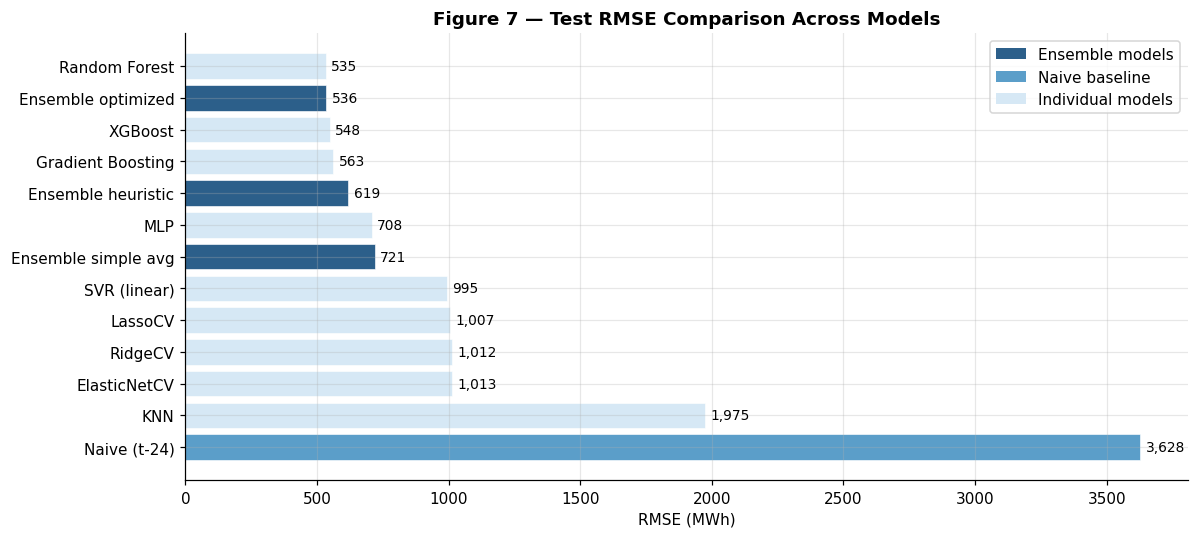

In [94]:
# Figure 7 — RMSE bar chart (all models)
df_plot = df_results.copy()

colors = []
for m in df_plot["Model"]:
    if "Ensemble" in m: colors.append("#2C5F8A")
    elif "Naive" in m: colors.append("#5B9EC9")
    else: colors.append("#D6E8F5")

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(df_plot["Model"], df_plot["RMSE (MWh)"], color=colors, edgecolor="white", lw=0.4)
for bar, v in zip(bars, df_plot["RMSE (MWh)"]):
    ax.text(v + 20, bar.get_y() + bar.get_height()/2, f"{v:,.0f}", va="center", fontsize=9)

legend_elements = [Patch(facecolor="#2C5F8A", label="Ensemble models"),
    Patch(facecolor="#5B9EC9", label="Naive baseline"),
    Patch(facecolor="#D6E8F5", label="Individual models")]

ax.legend(handles=legend_elements, loc="upper right")

ax.set_xlabel("RMSE (MWh)")
ax.set_title("Figure 7 — Test RMSE Comparison Across Models", fontsize=12, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("figures/fig7_rmse_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

The final comparison shows that the best models improve clearly over the seasonal naive baseline. This means that the calendar, lag, rolling, price, and weather features add useful information beyond simply using demand from the previous day.

Random Forest has the lowest test RMSE among the individual models. This suggests that nonlinear tree-based methods work well for this forecasting problem. The ensemble models also perform well, although they do not necessarily beat the best individual model on the test period.

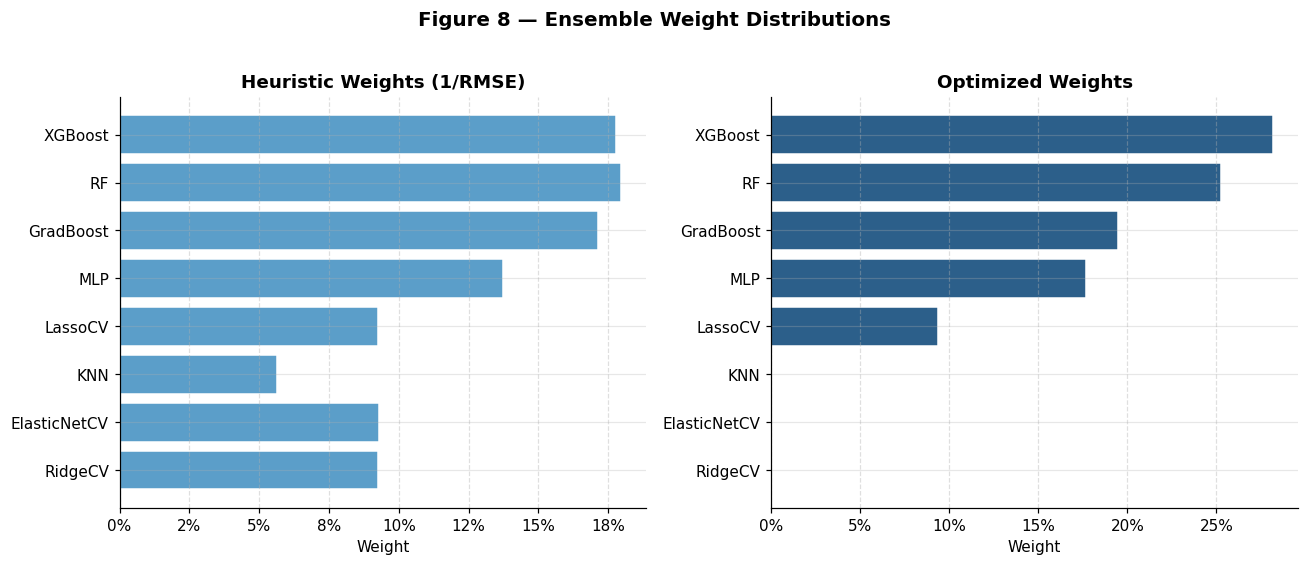

In [86]:
# Figure 8 — Ensemble weight distributions
weights_df = pd.DataFrame({
    "Model": names,
    "Heuristic": [weights_heuristic[name] for name in names],
    "Optimized": weights_optim
})

weights_df = weights_df.sort_values("Optimized")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Heuristic weights
axes[0].barh(weights_df["Model"], weights_df["Heuristic"], color="#5B9EC9", edgecolor="white")
axes[0].set_title("Heuristic Weights (1/RMSE)", fontweight="bold")
axes[0].set_xlabel("Weight")

# Optimized weights
axes[1].barh(weights_df["Model"], weights_df["Optimized"], color="#2C5F8A", edgecolor="white")
axes[1].set_title("Optimized Weights", fontweight="bold")
axes[1].set_xlabel("Weight")

for ax in axes:
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle("Figure 8 — Ensemble Weight Distributions", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig8_ensemble_weights.png", dpi=150, bbox_inches="tight")
plt.show()

The ensemble weight plots show how much each model contributes to the heuristic and optimized ensembles. Models with better validation performance receive more weight, while weaker or redundant models receive less.

Best ensemble: Optimized


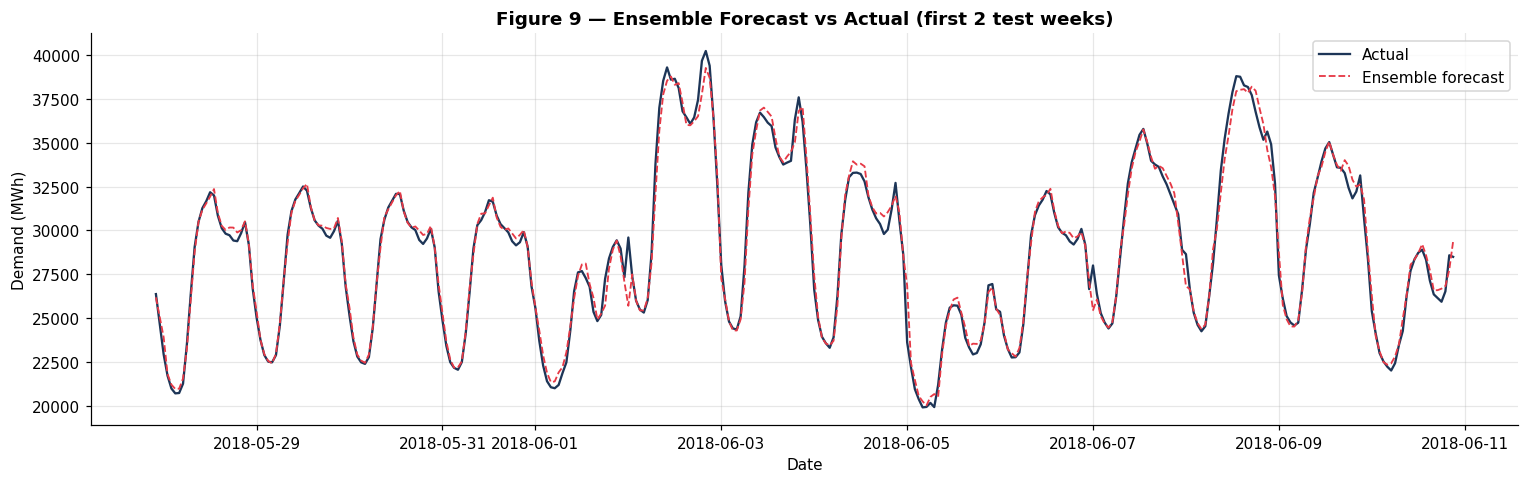

In [68]:
# Figure 9 — Predictions vs actual (2-week zoom) for best ensemble

# Choose best ensemble using validation RMSE
ensemble_val_rmse = {"Heuristic": rmse_ens_h_val, "Optimized": rmse_ens_o_val, "Simple average": rmse_ens_s_val}

best_ensemble_name = min(ensemble_val_rmse, key=ensemble_val_rmse.get)

if best_ensemble_name == "Heuristic":
    best_ens = y_pred_ens_h
elif best_ensemble_name == "Optimized":
    best_ens = y_pred_ens_o
else:
    best_ens = y_pred_ens_s

print("Best ensemble based on validation RMSE:", best_ensemble_name)

# Pick the first 2 weeks of the test set
zoom_n = 24 * 14
zoom_idx = y_test.index[:zoom_n]

fig, ax = plt.subplots(figsize=(14, 4.5))

ax.plot(zoom_idx, y_test.values[:zoom_n], color="#1D3557", lw=1.5, label="Actual")
ax.plot(zoom_idx, best_ens[:zoom_n], color="#E63946", lw=1.2, ls="--", label="Ensemble forecast")

ax.set_title("Figure 9 — Ensemble Forecast vs Actual (first 2 test weeks)", fontsize=12, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Demand (MWh)")
ax.legend()

plt.tight_layout()
plt.savefig("figures/fig9_forecast_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

The two-week forecast plot shows that the selected ensemble follows the main movements in electricity demand. It captures the daily pattern well, although some short-term peaks and troughs are still difficult to predict exactly.

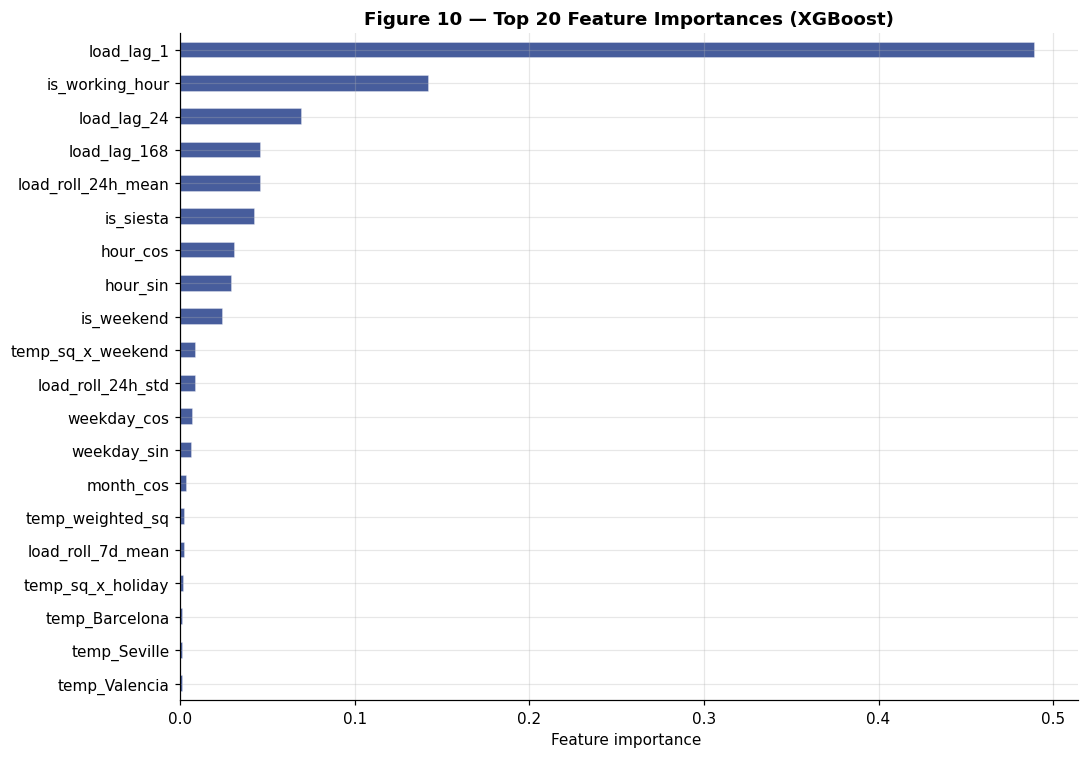

In [69]:
# Figure 10 — Feature importance (XGBoost)
imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
imp[::-1].plot(kind="barh", color="#27408b", edgecolor="white", alpha=0.85)
ax.set_title("Figure 10 — Top 20 Feature Importances (XGBoost)", fontsize=12, fontweight="bold")
ax.set_xlabel("Feature importance ")
plt.tight_layout()
plt.savefig("figures/fig10_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

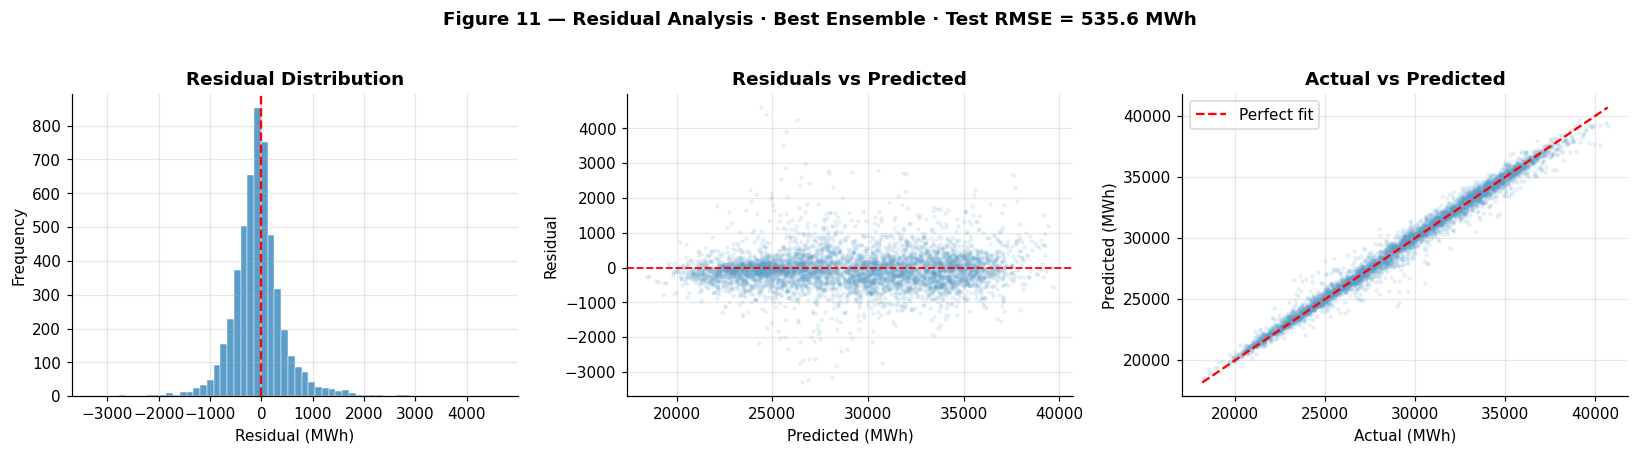

In [78]:
# Figure 11 — Residual analysis of the best ensemble
residuals = y_test.values - best_ens

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(residuals, bins=60, color="#5B9EC9", edgecolor="white", lw=0.3)
axes[0].axvline(0, color="red", lw=1.5, ls="--")
axes[0].set_title("Residual Distribution", fontweight="bold")
axes[0].set_xlabel("Residual (MWh)"); axes[0].set_ylabel("Frequency")

axes[1].scatter(best_ens, residuals, alpha=0.1, s=4, color="#5B9EC9")
axes[1].axhline(0, color="red", lw=1.2, ls="--")
axes[1].set_title("Residuals vs Predicted", fontweight="bold")
axes[1].set_xlabel("Predicted (MWh)"); axes[1].set_ylabel("Residual")

mn, mx = y_test.min(), y_test.max()
axes[2].scatter(y_test, best_ens, alpha=0.1, s=4, color="#5B9EC9")
axes[2].plot([mn, mx], [mn, mx], "r--", lw=1.5, label="Perfect fit")
axes[2].set_title("Actual vs Predicted", fontweight="bold")
axes[2].set_xlabel("Actual (MWh)"); axes[2].set_ylabel("Predicted (MWh)")
axes[2].legend()

ensemble_test_rmse = {"Heuristic": rmse_ens_h, "Optimized": rmse_ens_o, "Simple average": rmse_ens_s}
best_rmse = ensemble_test_rmse[best_ensemble_name]

plt.suptitle(f"Figure 11 — Residual Analysis · Best Ensemble · Test RMSE = {best_rmse:,.1f} MWh",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig11_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

The residual plots show that most forecast errors are centered around zero, which is a positive sign. However, some larger errors remain, especially during periods with sudden demand changes or unusual conditions.

### Overfitting check

To check for overfitting, we compare training RMSE with validation and test RMSE. A model may be overfitting if its training error is much lower than its validation or test error. This check is especially relevant for flexible models such as Random Forest, Gradient Boosting, XGBoost, and MLP. When the three errors are close, the model is more likely to generalize well.

In [71]:
# Check overfitting by comparing train, validation and test RMSE
def evaluate_split(model_name, y_train, y_train_pred, y_val, y_val_pred, y_test, y_test_pred):
    train_rmse = sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = sqrt(mean_squared_error(y_val, y_val_pred))
    test_rmse = sqrt(mean_squared_error(y_test, y_test_pred))
    
    val_train_ratio = np.nan if train_rmse == 0 else val_rmse / train_rmse
    test_train_ratio = np.nan if train_rmse == 0 else test_rmse / train_rmse
    
    return {
        "Model": model_name,
        "Train RMSE": train_rmse,
        "Validation RMSE": val_rmse,
        "Test RMSE": test_rmse,
        "Val / Train": val_train_ratio,
        "Test / Train": test_train_ratio
    }

# Train predictions
y_pred_naive_train = X_train["load_lag_24"].values
y_pred_ridge_train = ridge_cv_fine.predict(X_train_s)
y_pred_lasso_train = lasso_cv_fine.predict(X_train_s)
y_pred_elastic_train = elastic_cv_fine.predict(X_train_s)
y_pred_knn_train = knn.predict(X_train_s)
y_pred_svr_train = svr.predict(X_train_s)
y_pred_rf_train = rf.predict(X_train)
y_pred_gb_train = gb.predict(X_train)
y_pred_xgb_train = xgb_model.predict(X_train)
y_pred_mlp_train = mlp.predict(X_train_s)

overfit_rows = [
    evaluate_split("Naive", y_train, y_pred_naive_train, y_val, y_pred_naive_val, y_test, y_pred_naive_test),
    evaluate_split("RidgeCV", y_train, y_pred_ridge_train, y_val, y_pred_ridge_val, y_test, y_pred_ridge_test),
    evaluate_split("LassoCV", y_train, y_pred_lasso_train, y_val, y_pred_lasso_val, y_test, y_pred_lasso_test),
    evaluate_split("ElasticNetCV", y_train, y_pred_elastic_train, y_val, y_pred_elastic_val, y_test, y_pred_elastic_test),
    evaluate_split("KNN", y_train, y_pred_knn_train, y_val, y_pred_knn_val, y_test, y_pred_knn_test),
    evaluate_split("SVR", y_train, y_pred_svr_train, y_val, y_pred_svr_val, y_test, y_pred_svr_test),
    evaluate_split("Random Forest", y_train, y_pred_rf_train, y_val, y_pred_rf_val, y_test, y_pred_rf_test),
    evaluate_split("Gradient Boosting", y_train, y_pred_gb_train, y_val, y_pred_gb_val, y_test, y_pred_gb_test),
    evaluate_split("XGBoost", y_train, y_pred_xgb_train, y_val, y_pred_xgb_val, y_test, y_pred_xgb_test),
    evaluate_split("MLP", y_train, y_pred_mlp_train, y_val, y_pred_mlp_val, y_test, y_pred_mlp_test)
]

df_overfit = pd.DataFrame(overfit_rows)
df_overfit.round(3)

,Model,Train RMSE,Validation RMSE,Test RMSE,Val / Train,Test / Train
0,Naive,3506.791,3512.455,3627.658,1.002,1.034
1,RidgeCV,1055.546,1146.518,1011.971,1.086,0.959
2,LassoCV,1068.661,1147.093,1007.293,1.073,0.943
3,ElasticNetCV,1056.466,1144.177,1013.315,1.083,0.959
4,KNN,0.000,1886.183,1974.770,NaN,NaN
5,SVR,1086.379,1145.329,995.013,1.054,0.916
6,Random Forest,371.793,590.728,534.520,1.589,1.438
7,Gradient Boosting,497.111,619.831,562.623,1.247,1.132
8,XGBoost,394.802,596.986,547.775,1.512,1.387
9,MLP,519.616,772.361,708.318,1.486,1.363


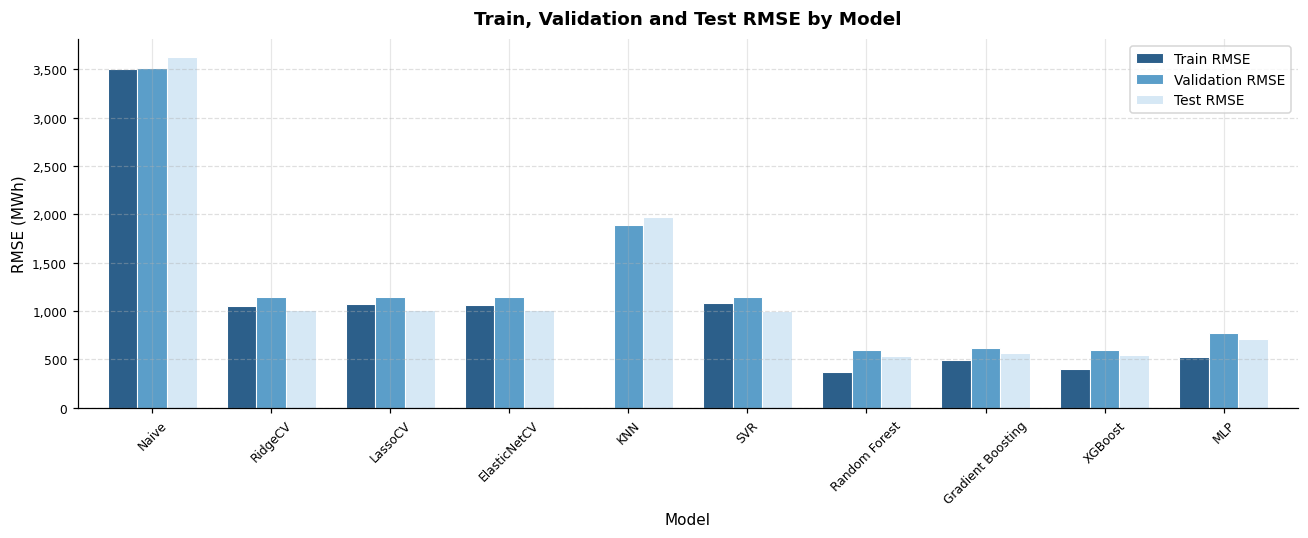

In [72]:
# Overfitting plot: Train, Validation and Test RMSE
df_overfit_plot = df_overfit.set_index("Model")[["Train RMSE", "Validation RMSE", "Test RMSE"]]

fig, ax = plt.subplots(figsize=(12, 5))

df_overfit_plot.plot(kind="bar", ax=ax, color=["#2C5F8A", "#5B9EC9", "#D6E8F5"],
    edgecolor="white", linewidth=0.7, width=0.75)

ax.set_title("Train, Validation and Test RMSE by Model", fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Model", fontsize=10)
ax.set_ylabel("RMSE (MWh)", fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", labelsize=8, rotation=45)
ax.tick_params(axis="y", labelsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="", fontsize=9)

plt.tight_layout()
plt.show()

The overfitting check shows that some flexible models, especially KNN and Random Forest, fit the training data much more closely than the validation and test data. This suggests some overfitting. In contrast, the regularized linear models have more similar train, validation, and test errors, which indicates more stable generalization.

---
# 6. References
